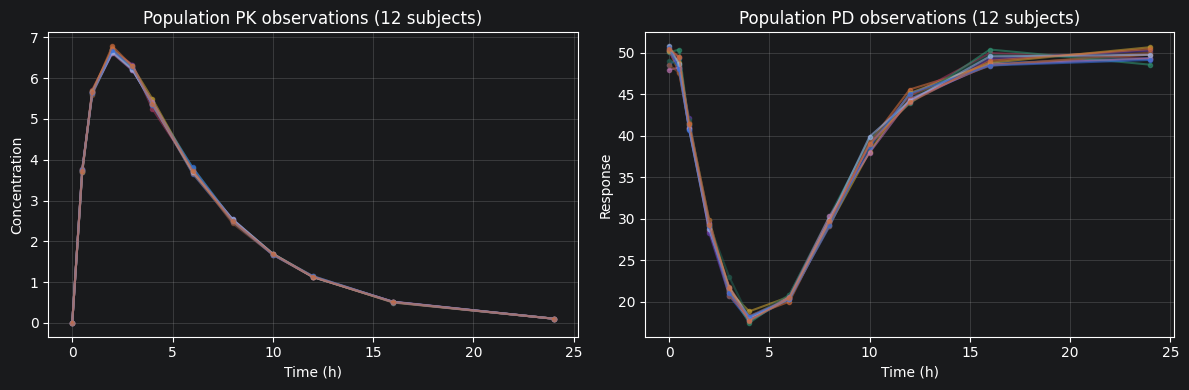

Population data ready.
pop_data shape = (144, 4)  (rows = 12 * 12)
X shape = torch.Size([144, 1]), Y shape = torch.Size([144, 1]), C_known shape = torch.Size([144, 1]), ID shape = torch.Size([144, 1])

Typical PD params (TV): {'Kin': 25.0, 'Kout': 0.5, 'Imax': 1.0, 'EC50': 4.0, 'gamma': 3.0}
First 3 sampled individual PD params:
  ID 0: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000
  ID 1: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000
  ID 2: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000


In [1]:
# ============================
# Cell 1 (Population): 导入包 + 生成群体 PK/PD 数据（12个体）
# ============================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# 可复现
np.random.seed(42)
torch.manual_seed(42)

# ----------------------------
# 0) 全局设定
# ----------------------------
n_subjects = 12
t_dense = np.linspace(0, 24, 241)  # 用于数值解真值
t_obs = np.array([0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

# PK 典型值（可视作已知机制）
tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)

# PD 典型值（我们希望后续识别）
tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)

# IIV（对数正态）标准差，表示 exp(eta), eta~N(0, omega^2)
# 可按需要调整
omega = dict(
    V=0.00, ka=0.00, ke=0.00,
    Kin=0.00, Kout=0.00, Imax=0.00, EC50=0.00
)

# 残差噪声水平
pd_noise_cv = 0.02   # 先用较小噪声
pk_noise_cv = 0.01

# ----------------------------
# 1) 个体参数采样函数
# ----------------------------
def sample_individual_params(tv_pk, tv_pd, omega):
    p = {}
    # PK
    p["D"] = tv_pk["D"]   # 剂量通常固定
    p["F"] = tv_pk["F"]
    p["V"]  = tv_pk["V"]  * np.exp(np.random.normal(0, omega["V"]))
    p["ka"] = tv_pk["ka"] * np.exp(np.random.normal(0, omega["ka"]))
    p["ke"] = tv_pk["ke"] * np.exp(np.random.normal(0, omega["ke"]))

    # 避免 ka≈ke 数值不稳定
    if abs(p["ka"] - p["ke"]) < 1e-3:
        p["ka"] = p["ke"] + 1e-3

    # PD
    p["Kin"]  = tv_pd["Kin"]  * np.exp(np.random.normal(0, omega["Kin"]))
    p["Kout"] = tv_pd["Kout"] * np.exp(np.random.normal(0, omega["Kout"]))
    p["Imax"] = tv_pd["Imax"] * np.exp(np.random.normal(0, omega["Imax"]))
    p["EC50"] = tv_pd["EC50"] * np.exp(np.random.normal(0, omega["EC50"]))
    p["gamma"] = tv_pd["gamma"]  # 先固定

    # 约束到合理范围
    p["Imax"] = np.clip(p["Imax"], 0.05, 1.5)
    p["EC50"] = max(p["EC50"], 1e-3)
    p["Kout"] = max(p["Kout"], 1e-4)
    p["Kin"]  = max(p["Kin"], 1e-4)
    return p

# ----------------------------
# 2) 用个体参数生成 C(t), R(t)
# ----------------------------
all_rows = []          # 每行: [ID, t, C_obs, R_obs]
subject_params = []    # 保存真实个体参数，后面评估用

for sid in range(n_subjects):
    p = sample_individual_params(tv_pk, tv_pd, omega)
    subject_params.append(p)

    # PK: Bateman
    pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
    C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
    C_dense = np.clip(C_dense, 0.0, None)
    C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

    # PD ODE
    def pd_ode(R, t):
        C_t = max(float(C_func(t)), 1e-8)
        hill = (C_t**p["gamma"]) / (p["EC50"]**p["gamma"] + C_t**p["gamma"])
        return p["Kin"] - (p["Kin"] * p["Imax"]) * hill - p["Kout"] * R

    R0 = p["Kin"] / p["Kout"]  # 个体基线
    R_dense = odeint(lambda r, tt: pd_ode(r, tt), R0, t_dense).flatten()

    # 观测点
    C_obs_clean = C_func(t_obs)
    R_obs_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)

    # 加噪声（比例噪声）
    C_obs = C_obs_clean * (1.0 + np.random.normal(0, pk_noise_cv, size=t_obs.shape))
    R_obs = R_obs_clean * (1.0 + np.random.normal(0, pd_noise_cv, size=t_obs.shape))

    C_obs = np.clip(C_obs, 0.0, None)

    for j, tt in enumerate(t_obs):
        all_rows.append([sid, tt, C_obs[j], R_obs[j]])

pop_data = np.array(all_rows, dtype=float)  # [N,4], N=12*12=144

# ----------------------------
# 3) 组装训练变量（先按你后面最小改造需求）
# ----------------------------
# 注意：目前先不加个体ID到网络输入，先做“pooled”版本
# X: time, Y: response, C_known: concentration (known input for library)
X_np = pop_data[:, 1:2]        # time
C_obs_np = pop_data[:, 2:3]    # observed C
Y_np = pop_data[:, 3:4]        # observed R
ID_np = pop_data[:, 0:1].astype(int)

X = torch.tensor(X_np, dtype=torch.float32)
Y = torch.tensor(Y_np, dtype=torch.float32)
C_known = torch.tensor(C_obs_np, dtype=torch.float32)
ID_tensor = torch.tensor(ID_np, dtype=torch.long)

# ----------------------------
# 4) 可视化
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sid in range(n_subjects):
    idx = (ID_np[:, 0] == sid)
    axes[0].plot(X_np[idx, 0], C_obs_np[idx, 0], '.-', alpha=0.6)
    axes[1].plot(X_np[idx, 0], Y_np[idx, 0], '.-', alpha=0.6)

axes[0].set_title(f"Population PK observations ({n_subjects} subjects)")
axes[0].set_xlabel("Time (h)")
axes[0].set_ylabel("Concentration")
axes[0].grid(alpha=0.3)

axes[1].set_title(f"Population PD observations ({n_subjects} subjects)")
axes[1].set_xlabel("Time (h)")
axes[1].set_ylabel("Response")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Population data ready.")
print(f"pop_data shape = {pop_data.shape}  (rows = {n_subjects} * {len(t_obs)})")
print(f"X shape = {X.shape}, Y shape = {Y.shape}, C_known shape = {C_known.shape}, ID shape = {ID_tensor.shape}")

print("\nTypical PD params (TV):", tv_pd)
print("First 3 sampled individual PD params:")
for i in range(min(3, n_subjects)):
    p = subject_params[i]
    print(f"  ID {i}: Kin={p['Kin']:.3f}, Kout={p['Kout']:.3f}, Imax={p['Imax']:.3f}, EC50={p['EC50']:.3f}, gamma={p['gamma']:.3f}")

In [2]:
# ============================
# Cell 2 : DeePyMoD数据封装 + 最小PD库
# Theta = [1, Hill(C), R]
# ============================
import torch
import torch.nn as nn
from torch.autograd import grad
from typing import Tuple

from deepymod import Library
from deepymod.data import Dataset, get_train_test_loader
from deepymod.utils.types import TensorList

# ---- 1) 手动标准化 ----
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = Y.mean(), Y.std()

Xn = (X - x_mean) / (x_std + 1e-8)
Yn = (Y - y_mean) / (y_std + 1e-8)

# C 不做 z-score，保留原始物理浓度
C_raw = C_known.clone()

print("Normalized tensors:")
print(f"Xn: mean={Xn.mean().item():.4f}, std={Xn.std().item():.4f}")
print(f"Yn: mean={Yn.mean().item():.4f}, std={Yn.std().item():.4f}")
print(f"C_raw: min={C_raw.min().item():.4f}, max={C_raw.max().item():.4f}")

# ---- 2) Dataset ----
def load_population_data_for_deepymod():
    return Xn.float(), Yn.float()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

dataset = Dataset(
    load_population_data_for_deepymod,
    preprocess_kwargs={
        "noise_level": 0.0,
        "normalize_coords": False,
        "normalize_data": False,
    },
    device=device
)
train_loader, test_loader = get_train_test_loader(dataset, train_test_split=0.8)

# ---- 3) Known C(t) 模块（按时间最近邻匹配）----
class KnownCFromTime(nn.Module):
    def __init__(self, Xn_ref: torch.Tensor, Cn_ref: torch.Tensor):
        super().__init__()
        self.register_buffer("Xref", Xn_ref.detach().clone())  # [N,1]
        self.register_buffer("Cref", Cn_ref.detach().clone())  # [N,1]

    def forward(self, x_query: torch.Tensor):
        # x_query [B,1], Xref [N,1]
        dist = torch.abs(x_query - self.Xref.T)  # [B,N]
        idx = torch.argmin(dist, dim=1)          # [B]
        c = self.Cref[idx]                       # [B,1]
        return c

known_c_module = KnownCFromTime(Xn.to(device), C_raw.to(device)).to(device)

# ---- 4) 最小PD库 ----
class PDLibraryMinimal(Library):
    def __init__(self, known_c: nn.Module):
        super().__init__()
        self.known_c = known_c
        # 用更接近真值的初始化更稳
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))  # softplus(4)≈4.018
        self.raw_gamma = nn.Parameter(torch.tensor(2.5)) # softplus(2.5)≈2.58

    def library(self, input):
        prediction, data = input
        R = prediction[:, 0:1]

        dRdt = grad(
            R, data,
            grad_outputs=torch.ones_like(R),
            create_graph=True,
            retain_graph=True
        )[0][:, 0:1]

        C = self.known_c(data).clamp_min(1e-8)  # 物理浓度域
        ec50 = torch.nn.functional.softplus(self.raw_ec50)
        gamma = torch.nn.functional.softplus(self.raw_gamma)

        hill = (C ** gamma) / (ec50 ** gamma + C ** gamma)

        one = torch.ones_like(R)
        theta = torch.cat([one, hill, R], dim=1)
        return [dRdt], [theta]

library = PDLibraryMinimal(known_c_module).to(device)

# ---- 5) 正确调试：pred 必须来自 data 的函数 ----
tmp_net = nn.Sequential(
    nn.Linear(1, 16), nn.Tanh(),
    nn.Linear(16, 16), nn.Tanh(),
    nn.Linear(16, 1)
).to(device)

for xb, yb in train_loader:
    xb = xb.to(device).requires_grad_(True)  # 必须 requires_grad
    pred = tmp_net(xb)                       # pred = f(xb) 才能对 xb 求导
    dts, thetas = library((pred, xb))
    print("Debug shapes:")
    print("  xb:", xb.shape, "pred:", pred.shape)
    print("  dRdt:", dts[0].shape, "theta:", thetas[0].shape)  # [B,1], [B,3]
    break

print("Cell 2 ready.")

Normalized tensors:
Xn: mean=-0.0000, std=1.0000
Yn: mean=-0.0000, std=1.0000
C_raw: min=0.0000, max=6.7860
Device: cuda
Preprocessing data
Dataset is using device:  cuda


D:\PycharmProjects\DeePyMoD\src\deepymod\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Debug shapes:
  xb: torch.Size([115, 1]) pred: torch.Size([115, 1])
  dRdt: torch.Size([115, 1]) theta: torch.Size([115, 3])
Cell 2 ready.


In [3]:
# ============================
# Cell 3 (revised): 更稳的最小训练策略
# ============================
import torch
import torch.nn as nn
from deepymod import DeepMoD
from deepymod.model.func_approx import NN
from deepymod.model.sparse_estimators import Threshold
import torch.nn.functional as F

# ---- 1) Ridge ----
class Ridge(nn.Module):
    def __init__(self, lam=1e-3):
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input):
        time_derivs, thetas = input
        if self.sparsity_masks is None:
            self.sparsity_masks = [
                torch.ones(theta.shape[1], dtype=torch.bool, device=theta.device)
                for theta in thetas
            ]

        sparse_thetas = [theta[:, mask] for theta, mask in zip(thetas, self.sparsity_masks)]

        coeff_vectors_sparse = []
        for theta_s, dt in zip(sparse_thetas, time_derivs):
            XtX = theta_s.T @ theta_s
            reg = self.lam * torch.eye(XtX.shape[0], device=XtX.device)
            Xty = theta_s.T @ dt
            try:
                w = torch.linalg.solve(XtX + reg, Xty)
            except RuntimeError:
                w = torch.linalg.pinv(XtX + reg) @ Xty
            coeff_vectors_sparse.append(w)

        full_coeffs = []
        for mask, w in zip(self.sparsity_masks, coeff_vectors_sparse):
            full = torch.zeros((mask.shape[0], 1), device=w.device)
            full[mask] = w
            full_coeffs.append(full)

        self.coeff_vectors = full_coeffs
        return full_coeffs

# ---- 2) model ----
network = NN(1, [64, 64, 64], 1).to(device)   # 稍增容量
estimator = Threshold(0.03)                    # 阈值略保守
constraint = Ridge(lam=1e-3)

model = DeepMoD(network, library, estimator, constraint).to(device)

optimizer_nn = torch.optim.Adam(model.func_approx.parameters(), lr=5e-4)
optimizer_lib = torch.optim.Adam(model.library.parameters(), lr=5e-5)

print("Init ec50,gamma:",
      F.softplus(model.library.raw_ec50).item(),
      F.softplus(model.library.raw_gamma).item())

# ---- 3) util ----
def eval_mse(model, loader):
    model.eval()
    val = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred, _ = model.func_approx(xb)
            val += torch.mean((pred - yb) ** 2).item()
            n += 1
    model.train()
    return val / max(n, 1)

# ---- 4) Stage A: strong pretrain NN ----
def pretrain_nn(model, train_loader, test_loader, n_epochs=4000):
    for p in model.library.parameters():
        p.requires_grad = False
    for p in model.func_approx.parameters():
        p.requires_grad = True

    best = 1e9
    bad = 0
    for ep in range(n_epochs):
        total = 0.0
        nb = 0
        for xb, yb in train_loader:
            xb = xb.to(device).requires_grad_(True)
            yb = yb.to(device)
            pred, _ = model.func_approx(xb)
            mse = torch.mean((pred - yb) ** 2)

            optimizer_nn.zero_grad()
            mse.backward()
            optimizer_nn.step()

            total += mse.item()
            nb += 1

        if ep % 200 == 0:
            tr = total / nb
            te = eval_mse(model, test_loader)
            print(f"[Pretrain] ep={ep}, train={tr:.4e}, val={te:.4e}")

        # 简单早停
        te = eval_mse(model, test_loader)
        if te < best - 1e-5:
            best = te
            bad = 0
        else:
            bad += 1
        if bad > 300:
            print(f"[Pretrain] early stop at ep={ep}, best_val={best:.4e}")
            break

# ---- 5) Stage B: alternating ----
def alternating_train(
    model, train_loader, test_loader,
    n_outer=8, n_inner=200,
    lambda_reg_start=0.02, lambda_reg_end=0.20,
    lambda_gamma=1e-3
):
    for outer in range(n_outer):
        print(f"\n[Outer {outer+1}/{n_outer}]")

        # 线性增大 reg 权重（关键）
        alpha = outer / max(n_outer - 1, 1)
        lambda_reg = lambda_reg_start * (1 - alpha) + lambda_reg_end * alpha

        # (1) NN 微调
        for p in model.library.parameters():
            p.requires_grad = False
        for p in model.func_approx.parameters():
            p.requires_grad = True

        for _ in range(200):
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)
                pred, _ = model.func_approx(xb)
                mse = torch.mean((pred - yb) ** 2)
                optimizer_nn.zero_grad()
                mse.backward()
                optimizer_nn.step()

        # (2) 更新稀疏 mask
        with torch.enable_grad():
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                pred, dts, ths = model(xb)
                break
            masks = estimator(ths, dts)
            model.constraint.sparsity_masks = masks

        # (3) 固定NN，更新库参数
        for p in model.func_approx.parameters():
            p.requires_grad = False
        for p in model.library.parameters():
            p.requires_grad = True

        for inner in range(n_inner):
            total_loss, total_mse, total_reg = 0.0, 0.0, 0.0
            nb = 0
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)

                pred, dts, ths = model(xb)
                mse = torch.mean((pred - yb) ** 2)

                coeffs = model.constraint_coeffs(sparse=True, scaled=False)
                reg = torch.mean(torch.stack([
                    torch.mean((dt - th @ cf) ** 2)
                    for dt, th, cf in zip(dts, ths, coeffs)
                ]))

                # 轻微约束 gamma 不要塌得过低（仅正则，不是硬限制）
                gamma_now = F.softplus(model.library.raw_gamma)

                loss = mse + lambda_reg * reg + lambda_gamma * gamma_now

                optimizer_lib.zero_grad()
                loss.backward()
                optimizer_lib.step()

                total_loss += loss.item()
                total_mse += mse.item()
                total_reg += reg.item()
                nb += 1

            if inner == n_inner - 1:
                print(f"  [Inner End] lambda_reg={lambda_reg:.3f} | "
                      f"loss={total_loss/nb:.4e} | mse={total_mse/nb:.4e} | reg={total_reg/nb:.4e}")

        val = eval_mse(model, test_loader)
        ec50_now = F.softplus(model.library.raw_ec50).item()
        gamma_now = F.softplus(model.library.raw_gamma).item()
        print(f"  [Val] mse={val:.4e}")
        print(f"  [Lib] ec50={ec50_now:.4f}, gamma={gamma_now:.4f}")
        print(f"  [Mask] {model.constraint.sparsity_masks[0].detach().cpu().numpy()}")

print("Start revised pretraining...")
pretrain_nn(model, train_loader, test_loader, n_epochs=4000)

print("\nStart revised alternating...")
alternating_train(
    model, train_loader, test_loader,
    n_outer=8, n_inner=200,
    lambda_reg_start=0.02, lambda_reg_end=0.20,  # 关键
    lambda_gamma=1e-3
)

print("\nCell 3 revised training done.")

Init ec50,gamma: 4.0181498527526855 2.578889846801758
Start revised pretraining...
[Pretrain] ep=0, train=1.0197e+00, val=1.0385e+00
[Pretrain] ep=200, train=1.0379e-02, val=5.6280e-03
[Pretrain] ep=400, train=8.9323e-03, val=4.4845e-03
[Pretrain] ep=600, train=7.3965e-03, val=3.8594e-03
[Pretrain] ep=800, train=5.8393e-03, val=3.9545e-03
[Pretrain] ep=1000, train=4.7469e-03, val=4.6127e-03
[Pretrain] early stop at ep=1118, best_val=3.6667e-03

Start revised alternating...

[Outer 1/8]
  [Inner End] lambda_reg=0.020 | loss=1.9450e-02 | mse=3.8063e-03 | reg=6.5276e-01
  [Val] mse=4.2229e-03
  [Lib] ec50=4.0279, gamma=2.5881
  [Mask] [ True  True  True]

[Outer 2/8]
  [Inner End] lambda_reg=0.046 | loss=2.5768e-02 | mse=2.8957e-03 | reg=4.4343e-01
  [Val] mse=3.3303e-03
  [Lib] ec50=4.0416, gamma=2.6011
  [Mask] [ True  True  True]

[Outer 3/8]
  [Inner End] lambda_reg=0.071 | loss=5.4304e-02 | mse=2.4125e-03 | reg=6.8989e-01
  [Val] mse=2.6449e-03
  [Lib] ec50=4.0560, gamma=2.6142
  [Ma

=== Sparse structure ===
Mask: [ True  True  True]
Coeff: [  4.183128  -15.853774   -3.3896022]

Discovered equation (normalized training space):
dR_norm/dt_norm = + 4.183128*1 - 15.853774*Hill(C) - 3.389602*R

=== Learned Hill params (physical C space) ===
EC50_hat  = 4.127531
gamma_hat = 2.680207

=== True typical PD params ===
Kin_true=25.0, Kout_true=0.5, Imax_true=1.0, EC50_true=4.0, gamma_true=3.0

=== Coefficient-derived quantities (normalized-space; trend only) ===
Kin_norm_hat  ~ 4.183128
Kout_norm_hat ~ 3.389602
Imax_norm_hat ~ 3.789933


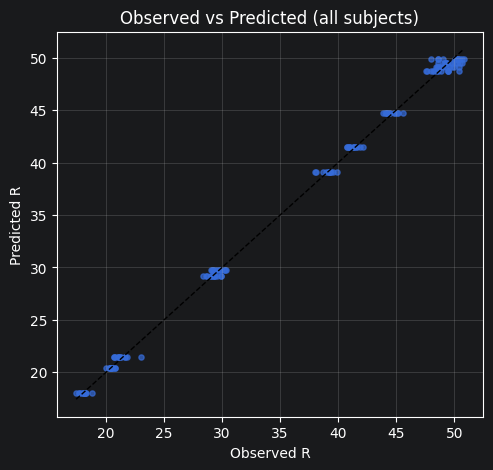

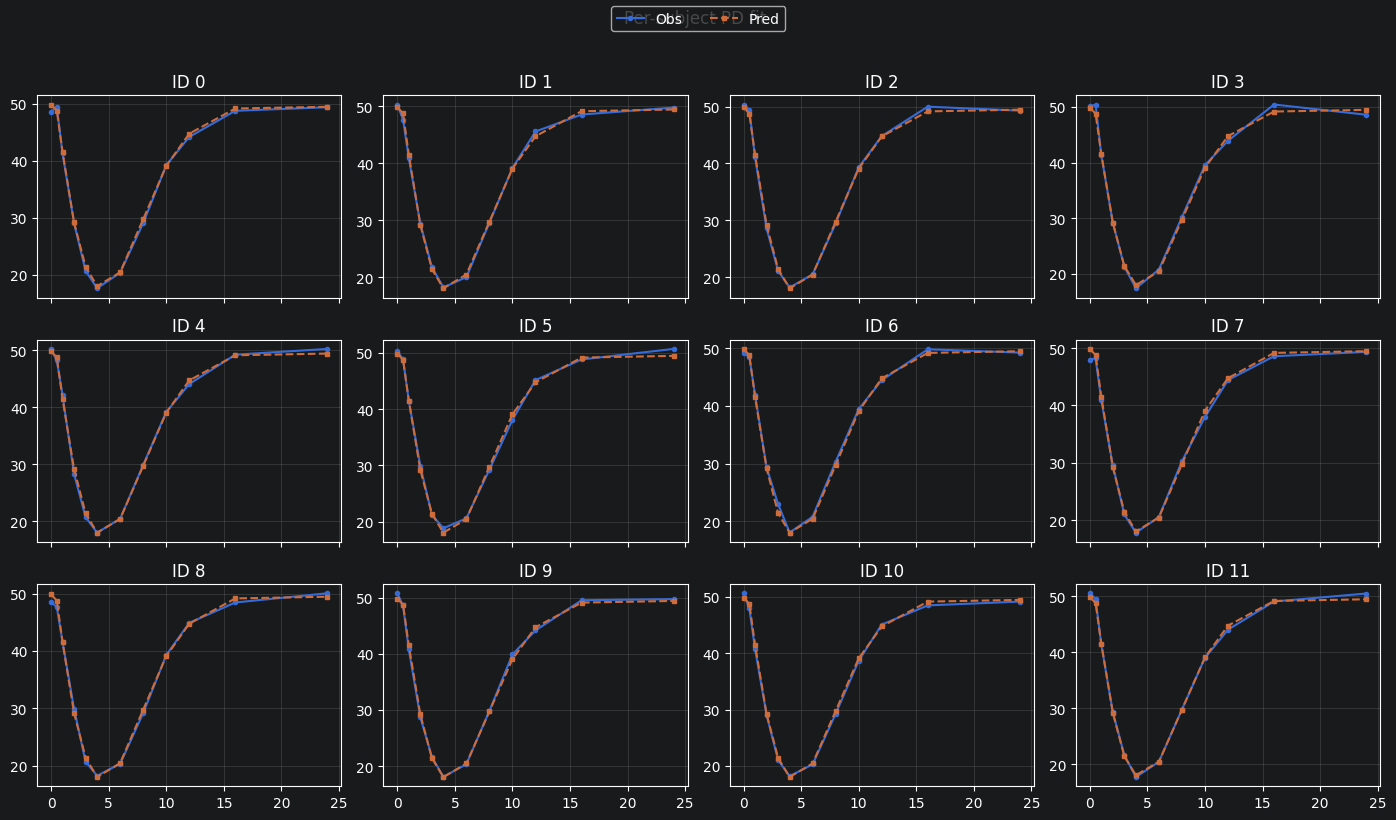


=== Quick diagnosis ===
结构识别：1 / Hill(C) / R 三项均被保留，与目标方程一致。
参数识别：EC50、gamma 直接可解释；Kin/Kout/Imax 建议在“未归一化R建模”或显式尺度变换后再做物理量精确还原。


In [4]:
# ============================
# Cell 4: 方程解码 + 参数对比 + 拟合可视化
# ============================
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

model.eval()

# ---- 1) 读取稀疏结构与系数 ----
mask = model.constraint.sparsity_masks[0].detach().cpu().numpy()             # [3]
coeff = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()   # [3]
term_names = ["1", "Hill(C)", "R"]

print("=== Sparse structure ===")
print("Mask:", mask)
print("Coeff:", coeff)

eq_parts = []
for m, c, n in zip(mask, coeff, term_names):
    if m:
        sign = "+" if c >= 0 else "-"
        eq_parts.append(f" {sign} {abs(c):.6f}*{n}")
eq_norm = "dR_norm/dt_norm =" + "".join(eq_parts) if len(eq_parts) else "No active terms."
print("\nDiscovered equation (normalized training space):")
print(eq_norm)

# ---- 2) 读取库参数（Hill）----
ec50_hat = F.softplus(model.library.raw_ec50).item()
gamma_hat = F.softplus(model.library.raw_gamma).item()

print("\n=== Learned Hill params (physical C space) ===")
print(f"EC50_hat  = {ec50_hat:.6f}")
print(f"gamma_hat = {gamma_hat:.6f}")

print("\n=== True typical PD params ===")
print(f"Kin_true={tv_pd['Kin']}, Kout_true={tv_pd['Kout']}, Imax_true={tv_pd['Imax']}, EC50_true={tv_pd['EC50']}, gamma_true={tv_pd['gamma']}")

# ---- 3) 系数含义（在归一化空间内）----
# 模型形式: dR/dt = a0 + a1*Hill(C) + a2*R
a0, a1, a2 = coeff
Kin_hat_norm  = a0
Kout_hat_norm = -a2
Imax_hat_norm = np.nan if abs(a0) < 1e-12 else (-a1 / a0)

print("\n=== Coefficient-derived quantities (normalized-space; trend only) ===")
print(f"Kin_norm_hat  ~ {Kin_hat_norm:.6f}")
print(f"Kout_norm_hat ~ {Kout_hat_norm:.6f}")
print(f"Imax_norm_hat ~ {Imax_hat_norm:.6f}")

# ---- 4) 预测 vs 观测可视化（按个体）----
with torch.no_grad():
    Xn_dev = Xn.to(device)
    pred_n, _ = model.func_approx(Xn_dev)          # normalized prediction
    pred_n = pred_n.cpu()
    # 反标准化回原始R量纲
    Y_pred = pred_n * (y_std + 1e-8) + y_mean      # [N,1]

Y_true = Y.cpu()
X_raw = X.cpu()
ID_np = ID_tensor.cpu().numpy().flatten()

# 整体散点：预测 vs 真实
plt.figure(figsize=(5.5, 5))
plt.scatter(Y_true.numpy(), Y_pred.numpy(), s=14, alpha=0.7)
mn = min(Y_true.min().item(), Y_pred.min().item())
mx = max(Y_true.max().item(), Y_pred.max().item())
plt.plot([mn, mx], [mn, mx], 'k--', lw=1)
plt.xlabel("Observed R")
plt.ylabel("Predicted R")
plt.title("Observed vs Predicted (all subjects)")
plt.grid(alpha=0.3)
plt.show()

# 分个体时序图
n_subjects_plot = int(ID_np.max()) + 1
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for sid in range(n_subjects_plot):
    ax = axes[sid]
    idx = (ID_np == sid)
    t_sid = X_raw[idx, 0].numpy()
    y_sid = Y_true[idx, 0].numpy()
    yp_sid = Y_pred[idx, 0].numpy()

    order = np.argsort(t_sid)
    t_sid, y_sid, yp_sid = t_sid[order], y_sid[order], yp_sid[order]

    ax.plot(t_sid, y_sid, 'o-', ms=3, label="Obs")
    ax.plot(t_sid, yp_sid, 's--', ms=3, label="Pred")
    ax.set_title(f"ID {sid}")
    ax.grid(alpha=0.25)

for j in range(n_subjects_plot, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle("Per-subject PD fit", y=1.02)
plt.tight_layout()
plt.show()

# ---- 5) 简要结论 ----
print("\n=== Quick diagnosis ===")
if mask.all():
    print("结构识别：1 / Hill(C) / R 三项均被保留，与目标方程一致。")
else:
    print("结构识别：有项被剔除，请检查阈值Threshold和lambda_reg。")

print("参数识别：EC50、gamma 直接可解释；Kin/Kout/Imax 建议在“未归一化R建模”或显式尺度变换后再做物理量精确还原。")

In [5]:
# ============================
# Cell 5: 从 normalized-space 系数还原到物理参数
# 适用前提：
# 1) Xn = (X - x_mean)/x_std
# 2) Yn = (Y - y_mean)/y_std
# 3) Library 用的是原始浓度 C（非标准化）
# 4) 方程形式: dYn/dXn = a0 + a1*Hill(C) + a2*Yn
# ============================
import numpy as np
import torch
import torch.nn.functional as F

# 读取系数
coeff = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()
a0, a1, a2 = coeff

# 标量化
x_std_val = float(x_std.cpu().item() if torch.is_tensor(x_std) else x_std)
y_std_val = float(y_std.cpu().item() if torch.is_tensor(y_std) else y_std)
y_mean_val = float(y_mean.cpu().item() if torch.is_tensor(y_mean) else y_mean)

# ---- 1) 系数从 normalized 方程映射回原方程 ----
# 已知:
# Yn = (R - y_mean)/y_std, Xn = (t - x_mean)/x_std
# => dYn/dXn = (x_std/y_std) * dR/dt
#
# 且 dYn/dXn = a0 + a1*Hill + a2*Yn
# 代入 Yn=(R-y_mean)/y_std，可得
# dR/dt = A + B*Hill + C*R
# 其中:
# A = (y_std/x_std)*(a0 - a2*y_mean/y_std)
# B = (y_std/x_std)*a1
# C = a2/x_std
A = (y_std_val / x_std_val) * (a0 - a2 * (y_mean_val / y_std_val))
B = (y_std_val / x_std_val) * a1
C = a2 / x_std_val

print("Recovered ODE coefficients in physical R,t space:")
print(f"dR/dt = A + B*Hill(C) + C*R")
print(f"A = {A:.6f}")
print(f"B = {B:.6f}")
print(f"C = {C:.6f}")

# ---- 2) 对应到药理参数 ----
# 目标方程: dR/dt = Kin - (Kin*Imax)*Hill(C) - Kout*R
Kin_hat = A
Kout_hat = -C
Imax_hat = np.nan if abs(Kin_hat) < 1e-12 else (-B / Kin_hat)

EC50_hat = F.softplus(model.library.raw_ec50).item()
gamma_hat = F.softplus(model.library.raw_gamma).item()

print("\nRecovered physical PD parameters:")
print(f"Kin_hat   = {Kin_hat:.6f}")
print(f"Kout_hat  = {Kout_hat:.6f}")
print(f"Imax_hat  = {Imax_hat:.6f}")
print(f"EC50_hat  = {EC50_hat:.6f}")
print(f"gamma_hat = {gamma_hat:.6f}")

# ---- 3) 与真值对比 ----
true_vals = {
    "Kin": tv_pd["Kin"],
    "Kout": tv_pd["Kout"],
    "Imax": tv_pd["Imax"],
    "EC50": tv_pd["EC50"],
    "gamma": tv_pd["gamma"],
}
hat_vals = {
    "Kin": Kin_hat,
    "Kout": Kout_hat,
    "Imax": Imax_hat,
    "EC50": EC50_hat,
    "gamma": gamma_hat,
}

print("\nComparison with true typical values:")
for k in ["Kin", "Kout", "Imax", "EC50", "gamma"]:
    tv = true_vals[k]
    hv = hat_vals[k]
    err = np.nan if tv == 0 else (hv - tv) / tv * 100
    print(f"{k:>6s}: true={tv:>8.4f} | hat={hv:>8.4f} | rel.err={err:>8.2f}%")

# ---- 4) 简要判定 ----
print("\nQuick check:")
if (Kout_hat > 0) and (Kin_hat > 0) and (Imax_hat > 0):
    print("参数符号合理（Kin>0, Kout>0, Imax>0）。")
else:
    print("参数符号异常，请检查训练或方程项符号。")

Recovered ODE coefficients in physical R,t space:
dR/dt = A + B*Hill(C) + C*R
A = 24.923260
B = -26.964371
C = -0.484722

Recovered physical PD parameters:
Kin_hat   = 24.923260
Kout_hat  = 0.484722
Imax_hat  = 1.081896
EC50_hat  = 4.127531
gamma_hat = 2.680207

Comparison with true typical values:
   Kin: true= 25.0000 | hat= 24.9233 | rel.err=   -0.31%
  Kout: true=  0.5000 | hat=  0.4847 | rel.err=   -3.06%
  Imax: true=  1.0000 | hat=  1.0819 | rel.err=    8.19%
  EC50: true=  4.0000 | hat=  4.1275 | rel.err=    3.19%
 gamma: true=  3.0000 | hat=  2.6802 | rel.err=  -10.66%

Quick check:
参数符号合理（Kin>0, Kout>0, Imax>0）。


In [6]:
# ============================
# Cell 6: 分阶段IIV + 多seed重复 + 参数分布统计
# 说明：
# - 复用你前面验证成功的思路（Hill用原始C）
# - 每个seed都会：生成数据 -> 训练 -> 还原参数
# - 分3个阶段：
#   S1: 仅 Kin/Kout 有IIV
#   S2: + EC50 IIV
#   S3: + gamma IIV
# ============================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.integrate import odeint
from scipy.interpolate import interp1d
import pandas as pd
from dataclasses import dataclass
from typing import Dict, List, Tuple

from deepymod import DeepMoD, Library
from deepymod.data import Dataset, get_train_test_loader
from deepymod.model.func_approx import NN
from deepymod.model.sparse_estimators import Threshold
from torch.autograd import grad

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- 真值 ----------
tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)
tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)

# ---------- 固定时间 ----------
t_dense = np.linspace(0, 24, 241)
t_obs = np.array([0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

# ---------- 训练超参（可按机器调整）----------
N_SUBJECTS = 12
PRETRAIN_EPOCHS = 1200
OUTER_STEPS = 6
INNER_STEPS = 120
NN_FINE_EPOCHS = 120
THRESHOLD = 0.03
RIDGE_LAM = 1e-3
LR_NN = 5e-4
LR_LIB = 5e-5
LAMBDA_REG_START = 0.02
LAMBDA_REG_END = 0.12

N_REPEATS = 20  # 先20次，跑稳后可改50

# ---------- 工具类 ----------
class Ridge(nn.Module):
    def __init__(self, lam=1e-3):
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input):
        time_derivs, thetas = input
        if self.sparsity_masks is None:
            self.sparsity_masks = [
                torch.ones(theta.shape[1], dtype=torch.bool, device=theta.device)
                for theta in thetas
            ]
        sparse_thetas = [theta[:, mask] for theta, mask in zip(thetas, self.sparsity_masks)]

        coeff_sparse = []
        for th, dt in zip(sparse_thetas, time_derivs):
            XtX = th.T @ th
            reg = self.lam * torch.eye(XtX.shape[0], device=th.device)
            Xty = th.T @ dt
            try:
                w = torch.linalg.solve(XtX + reg, Xty)
            except RuntimeError:
                w = torch.linalg.pinv(XtX + reg) @ Xty
            coeff_sparse.append(w)

        full = []
        for mask, w in zip(self.sparsity_masks, coeff_sparse):
            f = torch.zeros((mask.shape[0], 1), device=w.device)
            f[mask] = w
            full.append(f)

        self.coeff_vectors = full
        return full

class KnownCFromTime(nn.Module):
    def __init__(self, Xn_ref, Craw_ref):
        super().__init__()
        self.register_buffer("Xref", Xn_ref.detach().clone())   # [N,1]
        self.register_buffer("Cref", Craw_ref.detach().clone()) # [N,1]

    def forward(self, x_query):
        dist = torch.abs(x_query - self.Xref.T)  # [B,N]
        idx = torch.argmin(dist, dim=1)
        return self.Cref[idx]

class PDLibraryMinimal(Library):
    # theta = [1, Hill(C), R]
    def __init__(self, known_c_module):
        super().__init__()
        self.known_c = known_c_module
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))
        self.raw_gamma = nn.Parameter(torch.tensor(2.5))

    def library(self, input):
        prediction, data = input
        R = prediction[:, 0:1]
        dRdt = grad(
            R, data, grad_outputs=torch.ones_like(R),
            create_graph=True, retain_graph=True
        )[0][:, 0:1]

        C = self.known_c(data).clamp_min(1e-8)  # raw concentration
        ec50 = F.softplus(self.raw_ec50)
        gamma = F.softplus(self.raw_gamma)
        hill = (C ** gamma) / (ec50 ** gamma + C ** gamma)

        one = torch.ones_like(R)
        theta = torch.cat([one, hill, R], dim=1)
        return [dRdt], [theta]

# ---------- 数据模拟 ----------
def sample_lognormal(tv, omega):
    return tv * np.exp(np.random.normal(0, omega))

def simulate_population(seed: int, omega_stage: Dict[str, float], n_subjects=12):
    np.random.seed(seed)
    rows = []

    for sid in range(n_subjects):
        # PK：先不加IIV，保持“已知且稳定”
        p = dict(tv_pk)
        # PD IIV按阶段开启
        Kin   = sample_lognormal(tv_pd["Kin"],   omega_stage.get("Kin", 0.0))
        Kout  = sample_lognormal(tv_pd["Kout"],  omega_stage.get("Kout", 0.0))
        Imax  = sample_lognormal(tv_pd["Imax"],  omega_stage.get("Imax", 0.0))
        EC50  = sample_lognormal(tv_pd["EC50"],  omega_stage.get("EC50", 0.0))
        gamma = sample_lognormal(tv_pd["gamma"], omega_stage.get("gamma", 0.0))

        Imax = np.clip(Imax, 0.05, 1.5)
        EC50 = max(EC50, 1e-4)
        Kout = max(Kout, 1e-4)
        Kin = max(Kin, 1e-4)
        gamma = max(gamma, 0.2)

        # PK C(t)
        pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
        C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
        C_dense = np.clip(C_dense, 0, None)
        C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

        def pd_ode(R, t):
            C_t = max(float(C_func(t)), 1e-8)
            hill = (C_t**gamma) / (EC50**gamma + C_t**gamma)
            return Kin - (Kin * Imax) * hill - Kout * R

        R0 = Kin / Kout
        R_dense = odeint(lambda r, tt: pd_ode(r, tt), R0, t_dense).flatten()

        C_obs = C_func(t_obs) * (1 + np.random.normal(0, 0.01, size=t_obs.shape))
        R_obs_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)
        R_obs = R_obs_clean * (1 + np.random.normal(0, 0.02, size=t_obs.shape))
        C_obs = np.clip(C_obs, 0, None)

        for j, tt in enumerate(t_obs):
            rows.append([sid, tt, C_obs[j], R_obs[j]])

    pop = np.array(rows, dtype=float)  # [N,4]
    return pop

# ---------- 单次训练并还原参数 ----------
def run_once(seed: int, omega_stage: Dict[str, float]) -> Dict[str, float]:
    torch.manual_seed(seed)
    np.random.seed(seed)

    pop = simulate_population(seed, omega_stage, n_subjects=N_SUBJECTS)

    X = torch.tensor(pop[:, 1:2], dtype=torch.float32)
    C = torch.tensor(pop[:, 2:3], dtype=torch.float32)   # raw C
    Y = torch.tensor(pop[:, 3:4], dtype=torch.float32)

    # 标准化 X,Y；C保持raw
    x_mean, x_std = X.mean(), X.std()
    y_mean, y_std = Y.mean(), Y.std()
    Xn = (X - x_mean) / (x_std + 1e-8)
    Yn = (Y - y_mean) / (y_std + 1e-8)

    def load_data():
        return Xn.float(), Yn.float()

    dataset = Dataset(
        load_data,
        preprocess_kwargs={"noise_level": 0.0, "normalize_coords": False, "normalize_data": False},
        device=device
    )
    train_loader, test_loader = get_train_test_loader(dataset, train_test_split=0.8)

    known_c = KnownCFromTime(Xn.to(device), C.to(device)).to(device)
    library = PDLibraryMinimal(known_c).to(device)

    network = NN(1, [64, 64, 64], 1).to(device)
    estimator = Threshold(THRESHOLD)
    constraint = Ridge(lam=RIDGE_LAM)
    model = DeepMoD(network, library, estimator, constraint).to(device)

    opt_nn = torch.optim.Adam(model.func_approx.parameters(), lr=LR_NN)
    opt_lib = torch.optim.Adam(model.library.parameters(), lr=LR_LIB)

    def eval_mse(loader):
        model.eval()
        s, n = 0.0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                pred, _ = model.func_approx(xb)
                s += torch.mean((pred - yb) ** 2).item()
                n += 1
        model.train()
        return s / max(1, n)

    # A) pretrain NN
    for p in model.library.parameters():
        p.requires_grad = False
    for p in model.func_approx.parameters():
        p.requires_grad = True

    for ep in range(PRETRAIN_EPOCHS):
        for xb, yb in train_loader:
            xb = xb.to(device).requires_grad_(True)
            yb = yb.to(device)
            pred, _ = model.func_approx(xb)
            mse = torch.mean((pred - yb) ** 2)
            opt_nn.zero_grad()
            mse.backward()
            opt_nn.step()

    # B) alternating
    for outer in range(OUTER_STEPS):
        alpha = outer / max(OUTER_STEPS - 1, 1)
        lambda_reg = LAMBDA_REG_START * (1 - alpha) + LAMBDA_REG_END * alpha

        # NN finetune
        for p in model.library.parameters():
            p.requires_grad = False
        for p in model.func_approx.parameters():
            p.requires_grad = True

        for _ in range(NN_FINE_EPOCHS):
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)
                pred, _ = model.func_approx(xb)
                mse = torch.mean((pred - yb) ** 2)
                opt_nn.zero_grad()
                mse.backward()
                opt_nn.step()

        # update sparsity mask
        with torch.enable_grad():
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                pred, dts, ths = model(xb)
                break
            masks = estimator(ths, dts)
            model.constraint.sparsity_masks = masks

        # optimize library params
        for p in model.func_approx.parameters():
            p.requires_grad = False
        for p in model.library.parameters():
            p.requires_grad = True

        for _ in range(INNER_STEPS):
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)

                pred, dts, ths = model(xb)
                mse = torch.mean((pred - yb) ** 2)
                coeffs = model.constraint_coeffs(sparse=True, scaled=False)
                reg = torch.mean(torch.stack([
                    torch.mean((dt - th @ cf) ** 2)
                    for dt, th, cf in zip(dts, ths, coeffs)
                ]))
                loss = mse + lambda_reg * reg

                opt_lib.zero_grad()
                loss.backward()
                opt_lib.step()

    # 还原参数
    coeff = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()
    a0, a1, a2 = coeff
    x_std_val = float(x_std.item())
    y_std_val = float(y_std.item())
    y_mean_val = float(y_mean.item())

    A = (y_std_val / x_std_val) * (a0 - a2 * (y_mean_val / y_std_val))
    B = (y_std_val / x_std_val) * a1
    Ccoef = a2 / x_std_val

    Kin_hat = A
    Kout_hat = -Ccoef
    Imax_hat = np.nan if abs(Kin_hat) < 1e-12 else (-B / Kin_hat)
    EC50_hat = F.softplus(model.library.raw_ec50).item()
    gamma_hat = F.softplus(model.library.raw_gamma).item()

    mask = model.constraint.sparsity_masks[0].detach().cpu().numpy().astype(int)

    return {
        "seed": seed,
        "Kin_hat": Kin_hat,
        "Kout_hat": Kout_hat,
        "Imax_hat": Imax_hat,
        "EC50_hat": EC50_hat,
        "gamma_hat": gamma_hat,
        "mask_1": mask[0],
        "mask_Hill": mask[1],
        "mask_R": mask[2],
    }

# ---------- 三阶段设置 ----------
stages = {
    "S1_KinKout_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.00, "gamma": 0.00},
    "S2_plus_EC50_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.20, "gamma": 0.00},
    "S3_plus_gamma_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.20, "gamma": 0.15},
}

all_results = []

for stage_name, omega_stage in stages.items():
    print(f"\n===== Running {stage_name} =====")
    stage_rows = []
    for k in range(N_REPEATS):
        seed = 1000 + k
        try:
            row = run_once(seed, omega_stage)
            row["stage"] = stage_name
            stage_rows.append(row)
            print(f"  [{k+1:02d}/{N_REPEATS}] seed={seed} done | "
                  f"Kin={row['Kin_hat']:.2f}, Kout={row['Kout_hat']:.3f}, "
                  f"Imax={row['Imax_hat']:.3f}, EC50={row['EC50_hat']:.3f}, gamma={row['gamma_hat']:.3f}")
        except Exception as e:
            print(f"  [{k+1:02d}/{N_REPEATS}] seed={seed} FAILED: {repr(e)}")
    all_results.extend(stage_rows)

results_df = pd.DataFrame(all_results)

print("\n=== Raw results head ===")
print(results_df.head())

# ---------- 汇总统计 ----------
def summarize_stage(df_stage: pd.DataFrame):
    out = {}
    for p in ["Kin_hat", "Kout_hat", "Imax_hat", "EC50_hat", "gamma_hat"]:
        vals = df_stage[p].dropna().values
        if len(vals) == 0:
            out[p+"_mean"] = np.nan
            out[p+"_std"] = np.nan
            out[p+"_q2.5"] = np.nan
            out[p+"_q97.5"] = np.nan
        else:
            out[p+"_mean"] = np.mean(vals)
            out[p+"_std"] = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
            out[p+"_q2.5"] = np.percentile(vals, 2.5)
            out[p+"_q97.5"] = np.percentile(vals, 97.5)

    # 结构入选频率
    out["freq_1"] = df_stage["mask_1"].mean()
    out["freq_Hill"] = df_stage["mask_Hill"].mean()
    out["freq_R"] = df_stage["mask_R"].mean()
    out["n_runs"] = len(df_stage)
    return out

summary_rows = []
for st in results_df["stage"].unique():
    s = summarize_stage(results_df[results_df["stage"] == st])
    s["stage"] = st
    summary_rows.append(s)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[["stage", "n_runs",
                         "Kin_hat_mean","Kin_hat_q2.5","Kin_hat_q97.5",
                         "Kout_hat_mean","Kout_hat_q2.5","Kout_hat_q97.5",
                         "Imax_hat_mean","Imax_hat_q2.5","Imax_hat_q97.5",
                         "EC50_hat_mean","EC50_hat_q2.5","EC50_hat_q97.5",
                         "gamma_hat_mean","gamma_hat_q2.5","gamma_hat_q97.5",
                         "freq_1","freq_Hill","freq_R"]]

print("\n=== Summary by stage (95% empirical interval across repeats) ===")
print(summary_df.to_string(index=False))

# 可选：保存
# results_df.to_csv("stage_repeats_raw_results.csv", index=False)
# summary_df.to_csv("stage_repeats_summary.csv", index=False)

Device: cuda

===== Running S1_KinKout_IIV =====
Preprocessing data
Dataset is using device:  cuda
  [01/20] seed=1000 done | Kin=27.19, Kout=0.500, Imax=0.956, EC50=4.069, gamma=2.625
Preprocessing data
Dataset is using device:  cuda
  [02/20] seed=1001 done | Kin=34.08, Kout=0.759, Imax=0.823, EC50=3.969, gamma=2.549
Preprocessing data
Dataset is using device:  cuda
  [03/20] seed=1002 done | Kin=12.24, Kout=0.204, Imax=1.464, EC50=4.068, gamma=2.626
Preprocessing data
Dataset is using device:  cuda
  [04/20] seed=1003 done | Kin=23.67, Kout=0.403, Imax=1.137, EC50=4.068, gamma=2.626
Preprocessing data
Dataset is using device:  cuda
  [05/20] seed=1004 done | Kin=26.27, Kout=0.451, Imax=1.114, EC50=4.069, gamma=2.624
Preprocessing data
Dataset is using device:  cuda
  [06/20] seed=1005 done | Kin=28.22, Kout=0.634, Imax=0.947, EC50=4.067, gamma=2.624
Preprocessing data
Dataset is using device:  cuda
  [07/20] seed=1006 done | Kin=28.05, Kout=0.530, Imax=0.954, EC50=4.067, gamma=2.625

=== Bootstrap mean CI (95%) ===
            stage param  point_mean  boot_ci_low  boot_ci_high  n_runs
   S1_KinKout_IIV   Kin   24.078668    21.819963     26.314627      20
   S1_KinKout_IIV  Kout    0.457818     0.404506      0.513941      20
   S1_KinKout_IIV  Imax    1.057383     0.997889      1.121266      20
   S1_KinKout_IIV  EC50    4.062293     4.051433      4.068685      20
   S1_KinKout_IIV gamma    2.621595     2.613698      2.625830      20
 S2_plus_EC50_IIV   Kin   23.848883    21.530655     26.167775      20
 S2_plus_EC50_IIV  Kout    0.457650     0.404062      0.513058      20
 S2_plus_EC50_IIV  Imax    1.049468     0.988248      1.116298      20
 S2_plus_EC50_IIV  EC50    4.061049     4.049466      4.068037      20
 S2_plus_EC50_IIV gamma    2.620572     2.611206      2.625737      20
S3_plus_gamma_IIV   Kin   23.837936    21.451899     26.194900      20
S3_plus_gamma_IIV  Kout    0.457478     0.403266      0.513599      20
S3_plus_gamma_IIV  Imax    1.051324     0.989

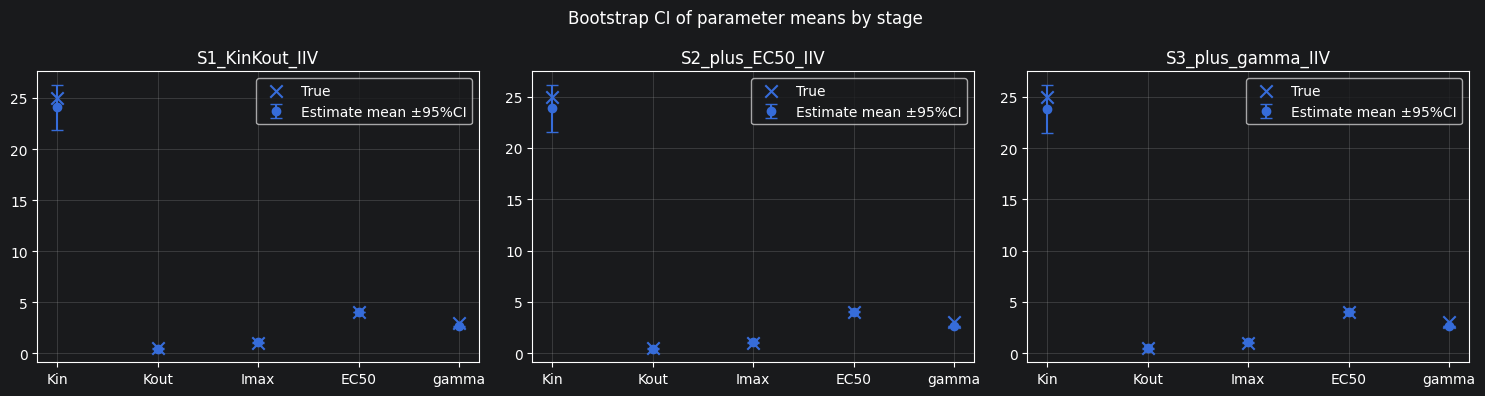

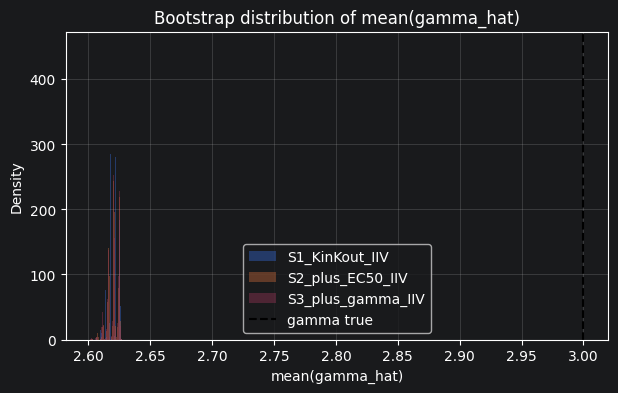

In [7]:
# ============================
# Cell 7: 对 results_df 做 bootstrap 置信区间（不重训）
# 依赖：上一格已得到 results_df
# 输出：
# 1) 各阶段各参数的 bootstrap 均值CI
# 2) 与真值对比的误差CI
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 基本检查 ----------
required_cols = ["stage", "Kin_hat", "Kout_hat", "Imax_hat", "EC50_hat", "gamma_hat"]
for c in required_cols:
    if c not in results_df.columns:
        raise ValueError(f"results_df 缺少列: {c}")

# 真值（沿用你前面定义）
true_vals = {
    "Kin_hat": tv_pd["Kin"],
    "Kout_hat": tv_pd["Kout"],
    "Imax_hat": tv_pd["Imax"],
    "EC50_hat": tv_pd["EC50"],
    "gamma_hat": tv_pd["gamma"],
}

params = ["Kin_hat", "Kout_hat", "Imax_hat", "EC50_hat", "gamma_hat"]

# ---------- bootstrap函数 ----------
def bootstrap_mean_ci(x, n_boot=5000, ci=95, seed=2026):
    """
    对样本x的均值做bootstrap CI
    返回: (mean, ci_low, ci_high, boot_means)
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, np.array([])
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))  # 重采样索引
    boot_means = x[idx].mean(axis=1)
    alpha = (100 - ci) / 2
    lo = np.percentile(boot_means, alpha)
    hi = np.percentile(boot_means, 100 - alpha)
    return x.mean(), lo, hi, boot_means

def bootstrap_rel_error_ci(x, true_value, n_boot=5000, ci=95, seed=2026):
    """
    对相对误差(%)的均值做bootstrap CI:
    rel_err = (mean_hat - true)/true * 100
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = x[idx].mean(axis=1)
    rel = (boot_means - true_value) / true_value * 100.0
    alpha = (100 - ci) / 2
    lo = np.percentile(rel, alpha)
    hi = np.percentile(rel, 100 - alpha)
    point = (x.mean() - true_value) / true_value * 100.0
    return point, lo, hi

# ---------- 按stage汇总 ----------
summary_rows = []
err_rows = []
boot_store = {}  # 可用于后续画分布

stages = list(results_df["stage"].unique())
for st in stages:
    sub = results_df[results_df["stage"] == st].copy()
    for p in params:
        mean_hat, lo, hi, boot_means = bootstrap_mean_ci(sub[p].values, n_boot=5000, ci=95, seed=2026)
        summary_rows.append({
            "stage": st,
            "param": p.replace("_hat", ""),
            "point_mean": mean_hat,
            "boot_ci_low": lo,
            "boot_ci_high": hi,
            "n_runs": len(sub)
        })
        boot_store[(st, p)] = boot_means

        point_err, err_lo, err_hi = bootstrap_rel_error_ci(
            sub[p].values, true_vals[p], n_boot=5000, ci=95, seed=2026
        )
        err_rows.append({
            "stage": st,
            "param": p.replace("_hat", ""),
            "point_rel_err_pct": point_err,
            "boot_rel_err_ci_low_pct": err_lo,
            "boot_rel_err_ci_high_pct": err_hi
        })

boot_summary_df = pd.DataFrame(summary_rows)
boot_err_df = pd.DataFrame(err_rows)

# 排序展示
param_order = ["Kin", "Kout", "Imax", "EC50", "gamma"]
boot_summary_df["param"] = pd.Categorical(boot_summary_df["param"], categories=param_order, ordered=True)
boot_err_df["param"] = pd.Categorical(boot_err_df["param"], categories=param_order, ordered=True)
boot_summary_df = boot_summary_df.sort_values(["stage", "param"]).reset_index(drop=True)
boot_err_df = boot_err_df.sort_values(["stage", "param"]).reset_index(drop=True)

print("=== Bootstrap mean CI (95%) ===")
print(boot_summary_df.to_string(index=False))

print("\n=== Bootstrap relative error CI (95%) ===")
print(boot_err_df.to_string(index=False))

# ---------- 可视化1：参数均值CI vs 真值 ----------
fig, axes = plt.subplots(1, len(stages), figsize=(5*len(stages), 4), sharey=False)
if len(stages) == 1:
    axes = [axes]

for ax, st in zip(axes, stages):
    sdf = boot_summary_df[boot_summary_df["stage"] == st].copy()
    xs = np.arange(len(param_order))
    means = sdf["point_mean"].values
    lows = sdf["boot_ci_low"].values
    highs = sdf["boot_ci_high"].values
    yerr = np.vstack([means - lows, highs - means])

    ax.errorbar(xs, means, yerr=yerr, fmt='o', capsize=4, label="Estimate mean ±95%CI")
    true_y = [tv_pd["Kin"], tv_pd["Kout"], tv_pd["Imax"], tv_pd["EC50"], tv_pd["gamma"]]
    ax.scatter(xs, true_y, marker='x', s=80, label="True", zorder=3)

    ax.set_xticks(xs)
    ax.set_xticklabels(param_order)
    ax.set_title(st)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Bootstrap CI of parameter means by stage")
plt.tight_layout()
plt.show()

# ---------- 可视化2：gamma的bootstrap均值分布 ----------
plt.figure(figsize=(7,4))
for st in stages:
    b = boot_store[(st, "gamma_hat")]
    plt.hist(b, bins=40, alpha=0.4, density=True, label=st)
plt.axvline(tv_pd["gamma"], color='k', linestyle='--', label='gamma true')
plt.title("Bootstrap distribution of mean(gamma_hat)")
plt.xlabel("mean(gamma_hat)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------- 可选保存 ----------
# boot_summary_df.to_csv("bootstrap_mean_ci_summary.csv", index=False)
# boot_err_df.to_csv("bootstrap_relative_error_ci_summary.csv", index=False)

=== Refit(Hill-only) head ===
   seed           stage    Kin_fix  Kout_fix  Imax_refit  EC50_refit  \
0  1000  S1_KinKout_IIV  27.193785  0.499542    0.963734    3.616538   
1  1001  S1_KinKout_IIV  34.080780  0.758999    0.832221    3.842905   
2  1002  S1_KinKout_IIV  12.243307  0.204180    1.464169    4.068356   
3  1003  S1_KinKout_IIV  23.672544  0.402669    1.119075    3.588598   
4  1004  S1_KinKout_IIV  26.271303  0.451184    1.119051    4.021744   

   gamma_refit   opt_cost  opt_success  opt_nfev  
0     2.798662  40.102020         True        16  
1     2.524123  40.322753         True        14  
2     2.625946  33.120061         True        13  
3     2.516244  52.484916         True        19  
4     2.656780  24.303359         True        13  

=== Refit(Hill-only) summary ===
            stage  n_runs  success_rate  Kin_fix_mean  Kout_fix_mean  Imax_refit_mean  Imax_refit_q2.5  Imax_refit_q97.5  EC50_refit_mean  EC50_refit_q2.5  EC50_refit_q97.5  gamma_refit_mean  gamma

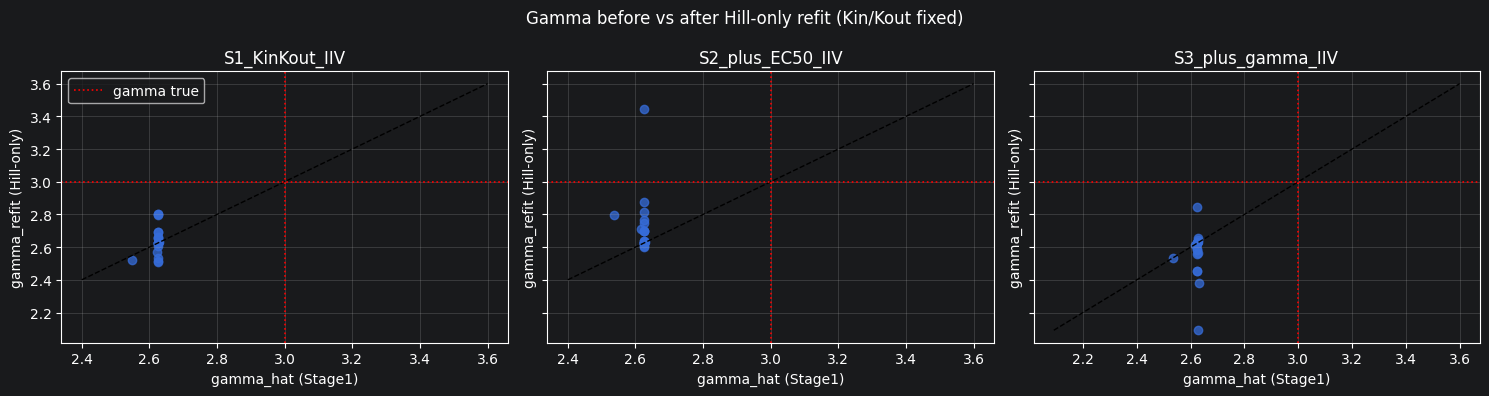

In [8]:
# ============================
# Cell 8b: 固定 Kin/Kout，仅精修 Imax/EC50/gamma
# 目的：减少参数补偿效应，专注修正 Hill 相关偏差（尤其 gamma）
# ============================
import numpy as np
import pandas as pd
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# --------- 依赖检查 ---------
need_cols = ["seed", "stage", "Kin_hat", "Kout_hat", "Imax_hat", "EC50_hat", "gamma_hat"]
for c in need_cols:
    if c not in results_df.columns:
        raise ValueError(f"results_df 缺少列: {c}")

if "tv_pk" not in globals():
    tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)
if "tv_pd" not in globals():
    tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)
if "t_dense" not in globals():
    t_dense = np.linspace(0, 24, 241)
if "t_obs" not in globals():
    t_obs = np.array([0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

N_SUBJECTS = 12

# 与 Cell6 一致
stage_omega_map = {
    "S1_KinKout_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.00, "gamma": 0.00},
    "S2_plus_EC50_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.20, "gamma": 0.00},
    "S3_plus_gamma_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.20, "gamma": 0.15},
}

def sample_lognormal(tv, omega):
    return tv * np.exp(np.random.normal(0, omega))

def simulate_population_for_refit(seed: int, omega_stage: dict, n_subjects=12):
    np.random.seed(seed)
    rows = []
    for sid in range(n_subjects):
        # PK fixed
        p = dict(tv_pk)

        # PD IIV
        Kin   = sample_lognormal(tv_pd["Kin"],   omega_stage.get("Kin", 0.0))
        Kout  = sample_lognormal(tv_pd["Kout"],  omega_stage.get("Kout", 0.0))
        Imax  = sample_lognormal(tv_pd["Imax"],  omega_stage.get("Imax", 0.0))
        EC50  = sample_lognormal(tv_pd["EC50"],  omega_stage.get("EC50", 0.0))
        gamma = sample_lognormal(tv_pd["gamma"], omega_stage.get("gamma", 0.0))

        Imax = np.clip(Imax, 0.05, 1.5)
        EC50 = max(EC50, 1e-4)
        Kout = max(Kout, 1e-4)
        Kin = max(Kin, 1e-4)
        gamma = max(gamma, 0.2)

        # PK
        pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
        C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
        C_dense = np.clip(C_dense, 0, None)
        C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

        def pd_ode(R, t):
            C_t = max(float(C_func(t)), 1e-8)
            hill = (C_t**gamma) / (EC50**gamma + C_t**gamma)
            return Kin - (Kin * Imax) * hill - Kout * R

        R0 = Kin / Kout
        R_dense = odeint(lambda r, tt: pd_ode(r, tt), R0, t_dense).flatten()

        C_obs = C_func(t_obs) * (1 + np.random.normal(0, 0.01, size=t_obs.shape))
        R_obs_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)
        R_obs = R_obs_clean * (1 + np.random.normal(0, 0.02, size=t_obs.shape))
        C_obs = np.clip(C_obs, 0, None)

        for j, tt in enumerate(t_obs):
            rows.append([sid, tt, C_obs[j], R_obs[j]])
    return np.array(rows, dtype=float)

def simulate_R_given_params(t, c, R0, Kin, Kout, Imax, EC50, gamma):
    Kin = max(Kin, 1e-8)
    Kout = max(Kout, 1e-8)
    Imax = np.clip(Imax, 1e-6, 1.5)
    EC50 = max(EC50, 1e-8)
    gamma = max(gamma, 0.2)

    C_func = interp1d(t, c, kind="linear", fill_value="extrapolate")

    def ode_fun(R, tt):
        Ct = max(float(C_func(tt)), 1e-8)
        hill = (Ct**gamma) / (EC50**gamma + Ct**gamma)
        return Kin - (Kin * Imax) * hill - Kout * R

    return odeint(lambda r, tt: ode_fun(r, tt), R0, t).flatten()

def refit_hill_only_one_seed(seed: int, stage: str, init_row: pd.Series):
    # 固定前一阶段估计的 Kin/Kout
    Kin_fix = float(max(init_row["Kin_hat"], 1e-8))
    Kout_fix = float(max(init_row["Kout_hat"], 1e-8))

    # 初值（只优化 Imax/EC50/gamma）
    Imax0 = float(np.clip(init_row["Imax_hat"], 0.05, 1.5))
    EC500 = float(max(init_row["EC50_hat"], 1e-4))
    gamma0 = float(max(init_row["gamma_hat"], 0.2))

    # 生成该seed对应数据
    pop = simulate_population_for_refit(seed, stage_omega_map[stage], n_subjects=N_SUBJECTS)
    sid_all = pop[:, 0].astype(int)
    t_all, c_all, r_all = pop[:, 1], pop[:, 2], pop[:, 3]

    sub_data = []
    for sid in range(N_SUBJECTS):
        idx = sid_all == sid
        t = t_all[idx]; c = c_all[idx]; r = r_all[idx]
        order = np.argsort(t)
        sub_data.append((t[order], c[order], r[order]))

    # 参数变换（保证可行域）
    # theta = [logit(Imax/1.5), log(EC50), log(gamma)]
    def to_theta(Imax, EC50, gamma):
        z = np.clip(Imax / 1.5, 1e-6, 1 - 1e-6)
        return np.array([np.log(z / (1 - z)), np.log(EC50), np.log(gamma)], dtype=float)

    def from_theta(theta):
        z = 1 / (1 + np.exp(-theta[0]))
        Imax = 1.5 * z
        EC50 = np.exp(theta[1])
        gamma = np.exp(theta[2])
        return Imax, EC50, gamma

    theta0 = to_theta(Imax0, EC500, gamma0)

    # 残差目标
    def residual(theta):
        Imax, EC50, gamma = from_theta(theta)
        res = []
        for t, c, r in sub_data:
            R0 = max(1e-8, r[0])  # 每个体首点初始化
            rp = simulate_R_given_params(t, c, R0, Kin_fix, Kout_fix, Imax, EC50, gamma)

            # 标准化残差
            scale = max(np.std(r), 1e-3)
            res.append((rp - r) / scale)

        # 弱正则：防止偏离stage1初值太夸张
        reg = np.array([
            (Imax - Imax0) / max(0.5 * Imax0, 1e-3),
            (EC50 - EC500) / max(0.5 * EC500, 1e-3),
            (gamma - gamma0) / max(0.5 * gamma0, 1e-3),
        ]) * 0.03
        return np.concatenate(res + [reg])

    opt = least_squares(
        residual,
        theta0,
        method="trf",
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=300
    )

    Imax_refit, EC50_refit, gamma_refit = from_theta(opt.x)

    return {
        "seed": seed,
        "stage": stage,
        "Kin_fix": Kin_fix,
        "Kout_fix": Kout_fix,
        "Imax_refit": float(Imax_refit),
        "EC50_refit": float(EC50_refit),
        "gamma_refit": float(gamma_refit),
        "opt_cost": float(opt.cost),
        "opt_success": bool(opt.success),
        "opt_nfev": int(opt.nfev),
    }

# ---------- 批量运行 ----------
rows = []
for _, r in results_df.iterrows():
    seed = int(r["seed"])
    stage = str(r["stage"])
    try:
        out = refit_hill_only_one_seed(seed, stage, r)
        rows.append(out)
    except Exception as e:
        rows.append({
            "seed": seed, "stage": stage,
            "Kin_fix": np.nan, "Kout_fix": np.nan,
            "Imax_refit": np.nan, "EC50_refit": np.nan, "gamma_refit": np.nan,
            "opt_cost": np.nan, "opt_success": False, "opt_nfev": np.nan
        })
        print(f"[WARN] seed={seed}, stage={stage} failed: {repr(e)}")

refit_hill_df = pd.DataFrame(rows)

print("=== Refit(Hill-only) head ===")
print(refit_hill_df.head())

# ---------- 汇总 ----------
def q(x, p): return np.nanpercentile(x, p)

summary = []
for st in refit_hill_df["stage"].dropna().unique():
    d = refit_hill_df[refit_hill_df["stage"] == st]
    row = {
        "stage": st,
        "n_runs": len(d),
        "success_rate": float(np.mean(d["opt_success"].astype(float))),
        "Kin_fix_mean": np.nanmean(d["Kin_fix"]),
        "Kout_fix_mean": np.nanmean(d["Kout_fix"]),
        "Imax_refit_mean": np.nanmean(d["Imax_refit"]),
        "Imax_refit_q2.5": q(d["Imax_refit"], 2.5),
        "Imax_refit_q97.5": q(d["Imax_refit"], 97.5),
        "EC50_refit_mean": np.nanmean(d["EC50_refit"]),
        "EC50_refit_q2.5": q(d["EC50_refit"], 2.5),
        "EC50_refit_q97.5": q(d["EC50_refit"], 97.5),
        "gamma_refit_mean": np.nanmean(d["gamma_refit"]),
        "gamma_refit_q2.5": q(d["gamma_refit"], 2.5),
        "gamma_refit_q97.5": q(d["gamma_refit"], 97.5),
    }
    summary.append(row)

refit_hill_summary_df = pd.DataFrame(summary)

print("\n=== Refit(Hill-only) summary ===")
print(refit_hill_summary_df.to_string(index=False))

print("\n=== Mean relative error vs true (Hill-only refit) ===")
for _, rr in refit_hill_summary_df.iterrows():
    st = rr["stage"]
    kin_e = (rr["Kin_fix_mean"] - tv_pd["Kin"]) / tv_pd["Kin"] * 100
    kout_e = (rr["Kout_fix_mean"] - tv_pd["Kout"]) / tv_pd["Kout"] * 100
    imax_e = (rr["Imax_refit_mean"] - tv_pd["Imax"]) / tv_pd["Imax"] * 100
    ec50_e = (rr["EC50_refit_mean"] - tv_pd["EC50"]) / tv_pd["EC50"] * 100
    gam_e = (rr["gamma_refit_mean"] - tv_pd["gamma"]) / tv_pd["gamma"] * 100
    print(f"{st}: Kin(fix) {kin_e:+.2f}% | Kout(fix) {kout_e:+.2f}% | "
          f"Imax {imax_e:+.2f}% | EC50 {ec50_e:+.2f}% | gamma {gam_e:+.2f}%")

# ---------- 可视化：gamma 精修前后 ----------
merged = results_df.merge(refit_hill_df, on=["seed", "stage"], how="inner")

fig, axes = plt.subplots(1, len(merged["stage"].unique()), figsize=(5*len(merged["stage"].unique()), 4), sharey=True)
stages = list(merged["stage"].unique())
if len(stages) == 1:
    axes = [axes]

for ax, st in zip(axes, stages):
    d = merged[merged["stage"] == st]
    ax.scatter(d["gamma_hat"], d["gamma_refit"], alpha=0.75)
    mn = min(d["gamma_hat"].min(), d["gamma_refit"].min(), tv_pd["gamma"]*0.8)
    mx = max(d["gamma_hat"].max(), d["gamma_refit"].max(), tv_pd["gamma"]*1.2)
    ax.plot([mn, mx], [mn, mx], "k--", lw=1)
    ax.axhline(tv_pd["gamma"], color="r", ls=":", lw=1.2, label="gamma true")
    ax.axvline(tv_pd["gamma"], color="r", ls=":", lw=1.2)
    ax.set_title(st)
    ax.set_xlabel("gamma_hat (Stage1)")
    ax.set_ylabel("gamma_refit (Hill-only)")
    ax.grid(alpha=0.3)

axes[0].legend()
plt.suptitle("Gamma before vs after Hill-only refit (Kin/Kout fixed)")
plt.tight_layout()
plt.show()

# 可选保存
# refit_hill_df.to_csv("stage2_refit_hill_only_raw.csv", index=False)
# refit_hill_summary_df.to_csv("stage2_refit_hill_only_summary.csv", index=False)

In [9]:
# ============================
# Cell 9b (FULL): 多剂量 + 2D输入(time,dose) 修正版
# 目的：
# - 修复Cell9中 KnownC 仅按时间匹配导致的跨剂量错配
# - 使用输入 X=[t_norm, dose_norm]，library只对time维求导
# - 其余流程保持与之前一致（分阶段IIV + 多seed重复）
# ============================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.integrate import odeint
from scipy.interpolate import interp1d
from torch.autograd import grad

from deepymod import DeepMoD, Library
from deepymod.data import Dataset, get_train_test_loader
from deepymod.model.func_approx import NN
from deepymod.model.sparse_estimators import Threshold

# ---------- device ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- true values ----------
tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)
tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)

# ---------- time grid ----------
t_dense = np.linspace(0, 24, 241)
t_obs = np.array([0, 0.25, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

# ---------- multi-dose design ----------
DOSE_LEVELS = [25.0, 50.0, 100.0, 200.0]
N_SUBJ_PER_DOSE = 6
N_SUBJECTS = len(DOSE_LEVELS) * N_SUBJ_PER_DOSE

# ---------- training hyperparams ----------
PRETRAIN_EPOCHS = 1400
OUTER_STEPS = 6
INNER_STEPS = 120
NN_FINE_EPOCHS = 120

THRESHOLD = 0.03
RIDGE_LAM = 1e-3
LR_NN = 5e-4
LR_LIB = 5e-5
LAMBDA_REG_START = 0.02
LAMBDA_REG_END = 0.12

N_REPEATS = 20  # 可改到50

# ---------- IIV stages ----------
stages = {
    "S1_KinKout_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.00, "gamma": 0.00},
    "S2_plus_EC50_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.20, "gamma": 0.00},
    "S3_plus_gamma_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.20, "gamma": 0.15},
}

# ============================
# Modules
# ============================

class Ridge(nn.Module):
    def __init__(self, lam=1e-3):
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input):
        time_derivs, thetas = input

        if self.sparsity_masks is None:
            self.sparsity_masks = [
                torch.ones(theta.shape[1], dtype=torch.bool, device=theta.device)
                for theta in thetas
            ]

        sparse_thetas = [theta[:, mask] for theta, mask in zip(thetas, self.sparsity_masks)]

        coeff_vectors_sparse = []
        for theta_s, dt in zip(sparse_thetas, time_derivs):
            XtX = theta_s.T @ theta_s
            reg = self.lam * torch.eye(XtX.shape[0], device=theta_s.device)
            Xty = theta_s.T @ dt
            try:
                w = torch.linalg.solve(XtX + reg, Xty)
            except RuntimeError:
                w = torch.linalg.pinv(XtX + reg) @ Xty
            coeff_vectors_sparse.append(w)

        coeff_vectors = []
        for mask, w in zip(self.sparsity_masks, coeff_vectors_sparse):
            full = torch.zeros((mask.shape[0], 1), device=w.device)
            full[mask] = w
            coeff_vectors.append(full)

        self.coeff_vectors = coeff_vectors
        return coeff_vectors


class KnownCFromInput(nn.Module):
    """
    根据2D输入 [t_norm, dose_norm] 做最近邻匹配，返回对应 raw C
    """
    def __init__(self, Xref, Cref):
        super().__init__()
        self.register_buffer("Xref", Xref.detach().clone())   # [N,2]
        self.register_buffer("Cref", Cref.detach().clone())   # [N,1]

    def forward(self, x_query):
        # x_query: [B,2], Xref:[N,2] -> dist:[B,N]
        dist = torch.cdist(x_query, self.Xref)
        idx = torch.argmin(dist, dim=1)
        return self.Cref[idx]


class PDLibraryMinimal2D(Library):
    """
    theta = [1, Hill(C), R]
    注意：导数只取 dR/dt (对输入第0维time求导)
    """
    def __init__(self, known_c_module):
        super().__init__()
        self.known_c = known_c_module
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))
        self.raw_gamma = nn.Parameter(torch.tensor(2.5))

    def library(self, input):
        prediction, data = input  # data:[N,2] => [t_norm, dose_norm]
        R = prediction[:, 0:1]

        dR_dX = grad(
            R, data,
            grad_outputs=torch.ones_like(R),
            create_graph=True,
            retain_graph=True
        )[0]  # [N,2]
        dRdt = dR_dX[:, 0:1]  # 只取time维

        C = self.known_c(data).clamp_min(1e-8)  # raw concentration
        ec50 = F.softplus(self.raw_ec50)
        gamma = F.softplus(self.raw_gamma)
        hill = (C ** gamma) / (ec50 ** gamma + C ** gamma)

        one = torch.ones_like(R)
        theta = torch.cat([one, hill, R], dim=1)
        return [dRdt], [theta]

# ============================
# Simulation
# ============================

def sample_lognormal(tv, omega):
    return tv * np.exp(np.random.normal(0, omega))


def simulate_population_multi_dose(seed: int, omega_stage: dict):
    """
    Return pop array columns:
      [sid, dose, time, C_obs, R_obs]
    """
    np.random.seed(seed)
    rows = []
    sid = 0

    for dose in DOSE_LEVELS:
        for _ in range(N_SUBJ_PER_DOSE):
            # PK
            p = dict(tv_pk)
            p["D"] = dose

            # PD with stage-specific IIV
            Kin   = sample_lognormal(tv_pd["Kin"],   omega_stage.get("Kin", 0.0))
            Kout  = sample_lognormal(tv_pd["Kout"],  omega_stage.get("Kout", 0.0))
            Imax  = sample_lognormal(tv_pd["Imax"],  omega_stage.get("Imax", 0.0))
            EC50  = sample_lognormal(tv_pd["EC50"],  omega_stage.get("EC50", 0.0))
            gamma = sample_lognormal(tv_pd["gamma"], omega_stage.get("gamma", 0.0))

            Imax = np.clip(Imax, 0.05, 1.5)
            EC50 = max(EC50, 1e-4)
            Kout = max(Kout, 1e-4)
            Kin = max(Kin, 1e-4)
            gamma = max(gamma, 0.2)

            # PK concentration curve
            pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
            C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
            C_dense = np.clip(C_dense, 0, None)
            C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

            # PD ODE
            def pd_ode(R, t):
                Ct = max(float(C_func(t)), 1e-8)
                hill = (Ct**gamma) / (EC50**gamma + Ct**gamma)
                return Kin - (Kin * Imax) * hill - Kout * R

            R0 = Kin / Kout
            R_dense = odeint(lambda r, tt: pd_ode(r, tt), R0, t_dense).flatten()

            # observations + noise
            C_obs = C_func(t_obs) * (1 + np.random.normal(0, 0.01, size=t_obs.shape))
            R_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)
            R_obs = R_clean * (1 + np.random.normal(0, 0.02, size=t_obs.shape))
            C_obs = np.clip(C_obs, 0, None)

            for j, tt in enumerate(t_obs):
                rows.append([sid, dose, tt, C_obs[j], R_obs[j]])
            sid += 1

    return np.array(rows, dtype=float)

# ============================
# Single run
# ============================

def run_once_multidose_2d(seed: int, omega_stage: dict):
    torch.manual_seed(seed)
    np.random.seed(seed)

    pop = simulate_population_multi_dose(seed, omega_stage)

    # columns: sid,dose,t,C,R
    dose_raw = torch.tensor(pop[:, 1:2], dtype=torch.float32)
    time_raw = torch.tensor(pop[:, 2:3], dtype=torch.float32)
    C_raw = torch.tensor(pop[:, 3:4], dtype=torch.float32)
    Y = torch.tensor(pop[:, 4:5], dtype=torch.float32)

    # normalize inputs separately
    t_mean, t_std = time_raw.mean(), time_raw.std()
    d_mean, d_std = dose_raw.mean(), dose_raw.std()
    y_mean, y_std = Y.mean(), Y.std()

    t_n = (time_raw - t_mean) / (t_std + 1e-8)
    d_n = (dose_raw - d_mean) / (d_std + 1e-8)
    Xn = torch.cat([t_n, d_n], dim=1)  # [N,2]
    Yn = (Y - y_mean) / (y_std + 1e-8)

    def load_data():
        return Xn.float(), Yn.float()

    dataset = Dataset(
        load_data,
        preprocess_kwargs={"noise_level": 0.0, "normalize_coords": False, "normalize_data": False},
        device=device
    )
    train_loader, test_loader = get_train_test_loader(dataset, train_test_split=0.8)

    known_c = KnownCFromInput(Xn.to(device), C_raw.to(device)).to(device)
    library = PDLibraryMinimal2D(known_c).to(device)

    # NN input dim = 2
    network = NN(2, [64, 64, 64], 1).to(device)
    estimator = Threshold(THRESHOLD)
    constraint = Ridge(lam=RIDGE_LAM)
    model = DeepMoD(network, library, estimator, constraint).to(device)

    optimizer_nn = torch.optim.Adam(model.func_approx.parameters(), lr=LR_NN)
    optimizer_lib = torch.optim.Adam(model.library.parameters(), lr=LR_LIB)

    # ---- Stage A: pretrain NN ----
    for p in model.library.parameters():
        p.requires_grad = False
    for p in model.func_approx.parameters():
        p.requires_grad = True

    for _ in range(PRETRAIN_EPOCHS):
        for xb, yb in train_loader:
            xb = xb.to(device).requires_grad_(True)
            yb = yb.to(device)
            pred, _ = model.func_approx(xb)
            mse = torch.mean((pred - yb) ** 2)

            optimizer_nn.zero_grad()
            mse.backward()
            optimizer_nn.step()

    # ---- Stage B: alternating ----
    for outer in range(OUTER_STEPS):
        alpha = outer / max(OUTER_STEPS - 1, 1)
        lambda_reg = LAMBDA_REG_START * (1 - alpha) + LAMBDA_REG_END * alpha

        # (1) NN finetune
        for p in model.library.parameters():
            p.requires_grad = False
        for p in model.func_approx.parameters():
            p.requires_grad = True

        for _ in range(NN_FINE_EPOCHS):
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)
                pred, _ = model.func_approx(xb)
                mse = torch.mean((pred - yb) ** 2)

                optimizer_nn.zero_grad()
                mse.backward()
                optimizer_nn.step()

        # (2) update masks
        with torch.enable_grad():
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                _, dts, ths = model(xb)
                break
            model.constraint.sparsity_masks = estimator(ths, dts)

        # (3) optimize library params
        for p in model.func_approx.parameters():
            p.requires_grad = False
        for p in model.library.parameters():
            p.requires_grad = True

        for _ in range(INNER_STEPS):
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)

                pred, dts, ths = model(xb)
                mse = torch.mean((pred - yb) ** 2)

                coeffs = model.constraint_coeffs(sparse=True, scaled=False)
                reg = torch.mean(torch.stack([
                    torch.mean((dt - th @ cf) ** 2)
                    for dt, th, cf in zip(dts, ths, coeffs)
                ]))

                loss = mse + lambda_reg * reg

                optimizer_lib.zero_grad()
                loss.backward()
                optimizer_lib.step()

    # ---- decode physical params ----
    coeff = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()
    a0, a1, a2 = coeff

    # IMPORTANT: derivative is wrt normalized time dimension only => use t_std
    t_std_val = float(t_std.item())
    y_std_val = float(y_std.item())
    y_mean_val = float(y_mean.item())

    A = (y_std_val / t_std_val) * (a0 - a2 * (y_mean_val / y_std_val))
    B = (y_std_val / t_std_val) * a1
    Ccoef = a2 / t_std_val

    Kin_hat = A
    Kout_hat = -Ccoef
    Imax_hat = np.nan if abs(Kin_hat) < 1e-12 else (-B / Kin_hat)
    EC50_hat = F.softplus(model.library.raw_ec50).item()
    gamma_hat = F.softplus(model.library.raw_gamma).item()

    mask = model.constraint.sparsity_masks[0].detach().cpu().numpy().astype(int)

    return {
        "seed": seed,
        "Kin_hat": Kin_hat,
        "Kout_hat": Kout_hat,
        "Imax_hat": Imax_hat,
        "EC50_hat": EC50_hat,
        "gamma_hat": gamma_hat,
        "mask_1": mask[0],
        "mask_Hill": mask[1],
        "mask_R": mask[2],
    }

# ============================
# Batch runs
# ============================

all_results = []

for stage_name, omega_stage in stages.items():
    print(f"\n===== Running stage: {stage_name} =====")
    for k in range(N_REPEATS):
        seed = 4000 + k
        try:
            row = run_once_multidose_2d(seed, omega_stage)
            row["stage"] = stage_name
            all_results.append(row)
            print(f"  [{k+1:02d}/{N_REPEATS}] seed={seed} done | "
                  f"Kin={row['Kin_hat']:.2f}, Kout={row['Kout_hat']:.3f}, "
                  f"Imax={row['Imax_hat']:.3f}, EC50={row['EC50_hat']:.3f}, gamma={row['gamma_hat']:.3f}")
        except Exception as e:
            print(f"  [{k+1:02d}/{N_REPEATS}] seed={seed} FAILED: {repr(e)}")

md2_results_df = pd.DataFrame(all_results)

print("\n=== md2_results_df head ===")
print(md2_results_df.head())

# ============================
# Summary
# ============================

def summarize_stage(df_stage):
    out = {}
    for p in ["Kin_hat", "Kout_hat", "Imax_hat", "EC50_hat", "gamma_hat"]:
        vals = df_stage[p].dropna().values
        if len(vals) == 0:
            out[p+"_mean"] = np.nan
            out[p+"_q2.5"] = np.nan
            out[p+"_q97.5"] = np.nan
        else:
            out[p+"_mean"] = np.mean(vals)
            out[p+"_q2.5"] = np.percentile(vals, 2.5)
            out[p+"_q97.5"] = np.percentile(vals, 97.5)

    out["freq_1"] = df_stage["mask_1"].mean()
    out["freq_Hill"] = df_stage["mask_Hill"].mean()
    out["freq_R"] = df_stage["mask_R"].mean()
    out["n_runs"] = len(df_stage)
    return out

summary_rows = []
for st in md2_results_df["stage"].unique():
    s = summarize_stage(md2_results_df[md2_results_df["stage"] == st])
    s["stage"] = st
    summary_rows.append(s)

md2_summary_df = pd.DataFrame(summary_rows)
md2_summary_df = md2_summary_df[[
    "stage", "n_runs",
    "Kin_hat_mean", "Kin_hat_q2.5", "Kin_hat_q97.5",
    "Kout_hat_mean", "Kout_hat_q2.5", "Kout_hat_q97.5",
    "Imax_hat_mean", "Imax_hat_q2.5", "Imax_hat_q97.5",
    "EC50_hat_mean", "EC50_hat_q2.5", "EC50_hat_q97.5",
    "gamma_hat_mean", "gamma_hat_q2.5", "gamma_hat_q97.5",
    "freq_1", "freq_Hill", "freq_R"
]]

print("\n=== Multi-dose (2D fixed) summary ===")
print(md2_summary_df.to_string(index=False))

print("\n=== Mean relative error vs true (multi-dose 2D fixed) ===")
for _, rr in md2_summary_df.iterrows():
    st = rr["stage"]
    kin_e = (rr["Kin_hat_mean"] - tv_pd["Kin"]) / tv_pd["Kin"] * 100
    kout_e = (rr["Kout_hat_mean"] - tv_pd["Kout"]) / tv_pd["Kout"] * 100
    imax_e = (rr["Imax_hat_mean"] - tv_pd["Imax"]) / tv_pd["Imax"] * 100
    ec50_e = (rr["EC50_hat_mean"] - tv_pd["EC50"]) / tv_pd["EC50"] * 100
    gam_e = (rr["gamma_hat_mean"] - tv_pd["gamma"]) / tv_pd["gamma"] * 100
    print(f"{st}: Kin {kin_e:+.2f}% | Kout {kout_e:+.2f}% | Imax {imax_e:+.2f}% | "
          f"EC50 {ec50_e:+.2f}% | gamma {gam_e:+.2f}%")

# optional save
# md2_results_df.to_csv("multi_dose_2d_fixed_raw.csv", index=False)
# md2_summary_df.to_csv("multi_dose_2d_fixed_summary.csv", index=False)

Device: cuda

===== Running stage: S1_KinKout_IIV =====
Preprocessing data
Dataset is using device:  cuda
  [01/20] seed=4000 done | Kin=19.68, Kout=0.376, Imax=1.065, EC50=4.069, gamma=2.627
Preprocessing data
Dataset is using device:  cuda
  [02/20] seed=4001 done | Kin=14.53, Kout=0.297, Imax=1.287, EC50=4.018, gamma=2.625
Preprocessing data
Dataset is using device:  cuda
  [03/20] seed=4002 done | Kin=19.49, Kout=0.382, Imax=1.067, EC50=4.065, gamma=2.625
Preprocessing data
Dataset is using device:  cuda
  [04/20] seed=4003 done | Kin=20.96, Kout=0.424, Imax=1.019, EC50=4.067, gamma=2.623
Preprocessing data
Dataset is using device:  cuda
  [05/20] seed=4004 done | Kin=23.64, Kout=0.441, Imax=1.084, EC50=4.069, gamma=2.631
Preprocessing data
Dataset is using device:  cuda
  [06/20] seed=4005 done | Kin=22.72, Kout=0.450, Imax=1.042, EC50=4.027, gamma=2.620
Preprocessing data
Dataset is using device:  cuda
  [07/20] seed=4006 done | Kin=18.42, Kout=0.327, Imax=1.186, EC50=4.068, gamm

In [12]:
# ============================
# Cell 10c: ID-embedding + grad-safe version
# ============================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from torch.autograd import grad
from deepymod.data import Dataset, get_train_test_loader
from deepymod.model.sparse_estimators import Threshold

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)
tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)

t_dense = np.linspace(0, 24, 241)
t_obs = np.array([0, 0.25, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

DOSE_LEVELS = [25.0, 50.0, 100.0, 200.0]
N_SUBJ_PER_DOSE = 6
N_SUBJECTS = len(DOSE_LEVELS) * N_SUBJ_PER_DOSE

PRETRAIN_EPOCHS = 500
OUTER_STEPS = 4
INNER_STEPS = 80
NN_FINE_EPOCHS = 60
THRESHOLD = 0.03
RIDGE_LAM = 1e-3
LR_NN = 5e-4
LR_LIB = 5e-5
LAMBDA_REG_START = 0.02
LAMBDA_REG_END = 0.10
N_REPEATS = 5
EMB_DIM = 4

stages = {
    "S1_KinKout_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.00, "gamma": 0.00},
    "S2_plus_EC50_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.20, "gamma": 0.00},
    "S3_plus_gamma_IIV": {"Kin": 0.20, "Kout": 0.20, "Imax": 0.00, "EC50": 0.20, "gamma": 0.15},
}

def sample_lognormal(tv, omega):
    return tv * np.exp(np.random.normal(0, omega))

def simulate_population_multi_dose(seed, omega_stage):
    np.random.seed(seed)
    rows = []
    sid = 0
    for dose in DOSE_LEVELS:
        for _ in range(N_SUBJ_PER_DOSE):
            p = dict(tv_pk); p["D"] = dose
            Kin   = sample_lognormal(tv_pd["Kin"],   omega_stage.get("Kin", 0.0))
            Kout  = sample_lognormal(tv_pd["Kout"],  omega_stage.get("Kout", 0.0))
            Imax  = sample_lognormal(tv_pd["Imax"],  omega_stage.get("Imax", 0.0))
            EC50  = sample_lognormal(tv_pd["EC50"],  omega_stage.get("EC50", 0.0))
            gamma = sample_lognormal(tv_pd["gamma"], omega_stage.get("gamma", 0.0))

            Imax = np.clip(Imax, 0.05, 1.5)
            EC50 = max(EC50, 1e-4); Kout=max(Kout,1e-4); Kin=max(Kin,1e-4); gamma=max(gamma,0.2)

            pre = (p["F"]*p["D"]*p["ka"])/(p["V"]*(p["ka"]-p["ke"]))
            C_dense = pre*(np.exp(-p["ke"]*t_dense)-np.exp(-p["ka"]*t_dense))
            C_dense = np.clip(C_dense,0,None)
            C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

            def pd_ode(R,t):
                Ct=max(float(C_func(t)),1e-8)
                hill=(Ct**gamma)/(EC50**gamma + Ct**gamma)
                return Kin-(Kin*Imax)*hill-Kout*R

            R0 = Kin/Kout
            R_dense = odeint(lambda r,tt: pd_ode(r,tt), R0, t_dense).flatten()

            C_obs = C_func(t_obs)*(1+np.random.normal(0,0.01,size=t_obs.shape))
            R_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)
            R_obs = R_clean*(1+np.random.normal(0,0.02,size=t_obs.shape))
            C_obs = np.clip(C_obs,0,None)

            for j,tt in enumerate(t_obs):
                rows.append([sid,dose,tt,C_obs[j],R_obs[j]])
            sid += 1
    return np.array(rows,dtype=float)

class FuncApproxWithID(nn.Module):
    def __init__(self, n_subjects, emb_dim=4):
        super().__init__()
        self.emb = nn.Embedding(n_subjects, emb_dim)
        self.net = nn.Sequential(
            nn.Linear(2+emb_dim,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,1)
        )

    def forward(self, x_full):
        # x_full: [N,4] => [t_n, d_n, sid, idx]
        coords = x_full[:, :2]   # must require grad before calling
        sid = x_full[:,2].long().clamp(min=0)
        emb = self.emb(sid)
        z = torch.cat([coords, emb], dim=1)
        pred = self.net(z)
        return pred, coords

class Ridge:
    def __init__(self, lam=1e-3):
        self.lam=lam
        self.sparsity_masks=None
        self.coeff_vectors=None

    def fit(self, dts, ths):
        if self.sparsity_masks is None:
            self.sparsity_masks=[torch.ones(ths[0].shape[1],dtype=torch.bool,device=ths[0].device)]
        m=self.sparsity_masks[0]
        th=ths[0][:,m]
        dt=dts[0]
        XtX=th.T@th
        reg=self.lam*torch.eye(XtX.shape[0],device=th.device)
        Xty=th.T@dt
        try:
            w=torch.linalg.solve(XtX+reg,Xty)
        except RuntimeError:
            w=torch.linalg.pinv(XtX+reg)@Xty
        full=torch.zeros((m.shape[0],1),device=th.device)
        full[m]=w
        self.coeff_vectors=[full]

    def sparse_coeffs(self):
        m=self.sparsity_masks[0]
        return [self.coeff_vectors[0][m]]

class PDLibraryWithIndex(nn.Module):
    def __init__(self, C_all):
        super().__init__()
        self.register_buffer("C_all", C_all)
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))
        self.raw_gamma = nn.Parameter(torch.tensor(2.5))

    def forward(self, pred, coords, idx_float):
        idx = idx_float.long().clamp(min=0, max=self.C_all.shape[0]-1)
        R = pred[:,0:1]

        dR_dX = grad(R, coords,
                     grad_outputs=torch.ones_like(R),
                     create_graph=True, retain_graph=True,
                     allow_unused=True)[0]
        if dR_dX is None:
            dR_dX = torch.zeros_like(coords)

        dRdt = dR_dX[:,0:1]
        C = self.C_all[idx].clamp_min(1e-8)

        ec50 = F.softplus(self.raw_ec50)
        gamma = F.softplus(self.raw_gamma)
        hill = (C**gamma)/(ec50**gamma + C**gamma)

        theta = torch.cat([torch.ones_like(R), hill, R], dim=1)
        return [dRdt],[theta]

def make_x_with_grad(xb):
    # 强制重建可导coords
    t = xb[:,0:1].clone().detach().requires_grad_(True)
    d = xb[:,1:2].clone().detach().requires_grad_(True)
    sid = xb[:,2:3].clone().detach()   # no grad
    idx = xb[:,3:4].clone().detach()   # no grad
    return torch.cat([t,d,sid,idx], dim=1)

def run_once(seed, omega):
    torch.manual_seed(seed); np.random.seed(seed)
    pop = simulate_population_multi_dose(seed, omega)

    sid  = torch.tensor(pop[:,0:1], dtype=torch.float32)
    dose = torch.tensor(pop[:,1:2], dtype=torch.float32)
    time = torch.tensor(pop[:,2:3], dtype=torch.float32)
    C    = torch.tensor(pop[:,3:4], dtype=torch.float32)
    Y    = torch.tensor(pop[:,4:5], dtype=torch.float32)

    t_mean,t_std = time.mean(),time.std()
    d_mean,d_std = dose.mean(),dose.std()
    y_mean,y_std = Y.mean(),Y.std()

    t_n = (time-t_mean)/(t_std+1e-8)
    d_n = (dose-d_mean)/(d_std+1e-8)
    y_n = (Y-y_mean)/(y_std+1e-8)
    idx = torch.arange(len(pop),dtype=torch.float32).unsqueeze(1)

    X = torch.cat([t_n,d_n,sid,idx], dim=1)

    def load_data():
        return X.float(), y_n.float()

    dataset = Dataset(load_data,
        preprocess_kwargs={"noise_level":0.0,"normalize_coords":False,"normalize_data":False},
        device=device
    )
    train_loader,_ = get_train_test_loader(dataset, train_test_split=0.8)

    func = FuncApproxWithID(N_SUBJECTS, EMB_DIM).to(device)
    lib = PDLibraryWithIndex(C.to(device)).to(device)
    ridge = Ridge(RIDGE_LAM)
    est = Threshold(THRESHOLD)

    opt_nn = torch.optim.Adam(func.parameters(), lr=LR_NN)
    opt_lib = torch.optim.Adam(lib.parameters(), lr=LR_LIB)

    # pretrain NN
    for p in lib.parameters(): p.requires_grad=False
    for _ in range(PRETRAIN_EPOCHS):
        for xb,yb in train_loader:
            xb,yb=xb.to(device),yb.to(device)
            xb2 = make_x_with_grad(xb)
            pred,_ = func(xb2)
            mse=((pred-yb)**2).mean()
            opt_nn.zero_grad(); mse.backward(); opt_nn.step()

    # alternating
    for outer in range(OUTER_STEPS):
        lam = LAMBDA_REG_START*(1-outer/max(1,OUTER_STEPS-1))+LAMBDA_REG_END*(outer/max(1,OUTER_STEPS-1))

        # nn finetune
        for p in lib.parameters(): p.requires_grad=False
        for p in func.parameters(): p.requires_grad=True
        for _ in range(NN_FINE_EPOCHS):
            for xb,yb in train_loader:
                xb,yb=xb.to(device),yb.to(device)
                xb2 = make_x_with_grad(xb)
                pred,_ = func(xb2)
                mse=((pred-yb)**2).mean()
                opt_nn.zero_grad(); mse.backward(); opt_nn.step()

        # mask update
        with torch.enable_grad():
            for xb,yb in train_loader:
                xb=xb.to(device)
                xb2 = make_x_with_grad(xb)
                pred,coords = func(xb2)
                dts,ths = lib(pred, coords, xb2[:,3])
                ridge.fit(dts,ths)
                ridge.sparsity_masks = est([ths[0]],[dts[0]])
                break

        # lib update
        for p in func.parameters(): p.requires_grad=False
        for p in lib.parameters(): p.requires_grad=True
        for _ in range(INNER_STEPS):
            for xb,yb in train_loader:
                xb,yb=xb.to(device), yb.to(device)
                xb2 = make_x_with_grad(xb)
                pred,coords = func(xb2)
                dts,ths = lib(pred, coords, xb2[:,3])
                ridge.fit(dts,ths)
                cf = ridge.sparse_coeffs()[0]
                m = ridge.sparsity_masks[0]
                mse=((pred-yb)**2).mean()
                reg=((dts[0]-ths[0][:,m]@cf)**2).mean()
                loss=mse+lam*reg
                opt_lib.zero_grad(); loss.backward(); opt_lib.step()

    # final coeff
    xb = X.to(device)
    xb2 = make_x_with_grad(xb)
    pred,coords = func(xb2)
    dts,ths = lib(pred,coords,xb2[:,3])
    ridge.fit(dts,ths)

    a0,a1,a2 = ridge.coeff_vectors[0].detach().cpu().numpy().flatten()
    t_std_val=float(t_std.item()); y_std_val=float(y_std.item()); y_mean_val=float(y_mean.item())

    A=(y_std_val/t_std_val)*(a0-a2*(y_mean_val/y_std_val))
    B=(y_std_val/t_std_val)*a1
    Ccoef=a2/t_std_val

    Kin_hat=A
    Kout_hat=-Ccoef
    Imax_hat=np.nan if abs(Kin_hat)<1e-12 else (-B/Kin_hat)
    EC50_hat=F.softplus(lib.raw_ec50).item()
    gamma_hat=F.softplus(lib.raw_gamma).item()

    m=ridge.sparsity_masks[0].detach().cpu().numpy().astype(int)
    return dict(seed=seed,Kin_hat=Kin_hat,Kout_hat=Kout_hat,Imax_hat=Imax_hat,
                EC50_hat=EC50_hat,gamma_hat=gamma_hat,mask_1=m[0],mask_Hill=m[1],mask_R=m[2])

# batch
rows=[]
for st,omega in stages.items():
    print(f"\n===== Running stage: {st} =====")
    for k in range(N_REPEATS):
        sd=7000+k
        try:
            r=run_once(sd,omega); r["stage"]=st; rows.append(r)
            print(f"[{k+1:02d}/{N_REPEATS}] seed={sd} Kin={r['Kin_hat']:.2f} Kout={r['Kout_hat']:.3f} Imax={r['Imax_hat']:.3f} EC50={r['EC50_hat']:.3f} gamma={r['gamma_hat']:.3f}")
        except Exception as e:
            print(f"[{k+1:02d}/{N_REPEATS}] seed={sd} FAILED: {repr(e)}")

id10c_results_df=pd.DataFrame(rows)
print("\nhead:")
print(id10c_results_df.head())

Device: cuda

===== Running stage: S1_KinKout_IIV =====
Preprocessing data
Dataset is using device:  cuda
[01/5] seed=7000 Kin=8.89 Kout=0.185 Imax=1.604 EC50=4.039 gamma=2.599
Preprocessing data
Dataset is using device:  cuda
[02/5] seed=7001 Kin=5.66 Kout=0.111 Imax=2.132 EC50=4.040 gamma=2.599
Preprocessing data
Dataset is using device:  cuda
[03/5] seed=7002 Kin=7.90 Kout=0.160 Imax=1.734 EC50=4.040 gamma=2.599
Preprocessing data
Dataset is using device:  cuda
[04/5] seed=7003 Kin=8.85 Kout=0.193 Imax=1.536 EC50=4.040 gamma=2.599
Preprocessing data
Dataset is using device:  cuda
[05/5] seed=7004 Kin=4.99 Kout=0.103 Imax=2.476 EC50=4.040 gamma=2.599

===== Running stage: S2_plus_EC50_IIV =====
Preprocessing data
Dataset is using device:  cuda
[01/5] seed=7000 Kin=9.03 Kout=0.192 Imax=1.460 EC50=4.039 gamma=2.599
Preprocessing data
Dataset is using device:  cuda
[02/5] seed=7001 Kin=4.36 Kout=0.086 Imax=2.358 EC50=4.040 gamma=2.599
Preprocessing data
Dataset is using device:  cuda
[0